# Анализ лояльности пользователей Яндекс Афиши с помощью Python

- Автор: Романов Артём
- Дата: 30.03.2026

### Цели и задачи проекта

Необходимо понять поведение пользователей, а именно какие паользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит выявлять перспективных клиентов и предлагать им персонализированные условия, точно настроивать рекламу, оптимизировать бюджет и повысить общий уровеьн удержания клиентов.

### Описание данных

Выгрузка из базы данных SQL позволила собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (**mobile** — мобильные устройства, **desktop** — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа;
- `order_ts` — дата и время создания заказа;
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия;
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

Также в ходе проекта будет использован датасет `final_tickets_tenge_df.csv` в котором есть информация о курсе казахстанского тенге по отношению к российскому рублю за 2024 год:

- `data` - дата курса	
- `nominal` - константа обмена (100 тенге)	
- `curs` - занчение в рублях для 100 тенге
- `cdx` - в какой валюте указан курс (в казахстанском тенге)

### Содержимое проекта

1. **Шаг 1. Загрузка данных и их предобработка**
    * Написать SQL-запрос, выгружающий в даатфрейм pandas необходимые данные
    * Изучить общую информацию о выгруженных данных
<br>

2. **Шаг 2. Предобработка данных**
   * Привести выручку к единой валюте, российскому рублю, с помощью датасета `final_tickets_tenge_df.csv`
   * Проверить данные на пропущенные значения
   * Преобразовать тип данных в столбцах, в которых это необъодимо
   * Изучить значения в ключевых столбцах, обработать ошибки, выбросы
   
<br>

3. **Шаг 3. Создание профиля пользователя**
* Построить профиль пользователя. Для каждого пользователя найти:
    * дату первого и последнего заказа;
    * устройство, с которого был сделан первый заказ;
    * регион, в котором был сделан первый заказ;
    * билетного партнёра, к которому обращались при первом заказе;
    * жанр первого посещённого мероприятия;
    * общее количество заказов;
    * средняя выручка с одного заказа в рублях;
    * среднее количество билетов в заказе;
    * среднее время между заказами.

* Добавить два бинарных признака:
    * `is_two` — совершил ли пользователь 2 и более заказа;
    * `is_five` — совершил ли пользователь 5 и более заказов.

* Используя данные о профилях пользователей, рассчитать:
    * общее число пользователей в выборке;
    * среднюю выручку с одного заказа;
    * долю пользователей, совершивших 2 и более заказа;
    * долю пользователей, совершивших 5 и более заказов.

* Изучить статистические показатели: 
    * по общему числу заказов;
    * по среднему числу билетов в заказе;
    * по среднему количеству дней между покупками.
<br>

4. **Шаг 4. Исследовательский анализ данных**

5. **Шаг 5. Общие выводы и рекомендации**
* Написать общий вывод и рекомендации для заказчика

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

**Задача 1.1:** Напишите SQL-запрос, выгружающий в датафрейм pandas необходимые данные. Используйте следующие параметры для подключения к базе данных `data-analyst-afisha`:

- **Хост** — `rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net`
- **База данных** — `data-analyst-afisha`
- **Порт** — `6432`
- **Аутентификация** — `Database Native`
- **Пользователь** — `praktikum_student`
- **Пароль** — `Sdf4$2;d-d30pp`

Для выгрузки используйте запрос из предыдущего урока и библиотеку SQLAlchemy.

Выгрузка из базы данных SQL должна позволить собрать следующие данные:

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


Импортируем бибилиотеки, которые нам необходимы для выполнения задачи:

* `pandas` - для работы с датафреймами
* `numpy` - для работы с Series, перцентилями
* `matplotlib.pyplot` - для визаулизации графиков
* `seaborn`  - для визаулизации тепловой карты
* `phik` - для корреляции `phi_k`
* `sqlalchemy` - для импорта датасета из  СУБД
*  `sys` - для работы с другими ноутбуками
* `warnings` - для сокрытия незначительных ошибок

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
import phik

from sqlalchemy import create_engine

import sys

import warnings
warnings.filterwarnings('ignore')

Займёмся импортом данных

In [2]:
sys.path.append('../src')

from load_data import load_data

df = load_data()

In [3]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


Импорт данных прошёл успешно, теперь можно работать с данными! 

---

**Задача 1.2:** Изучите общую информацию о выгруженных данных. Оцените корректность выгрузки и объём полученных данных.

Предположите, какие шаги необходимо сделать на стадии предобработки данных — например, скорректировать типы данных.

Зафиксируйте основную информацию о данных в кратком промежуточном выводе.

---

Посмотрим размер выгруженного датасета

In [4]:
df.shape

(290611, 15)

В детасете 290611 строк и 16 столбцов. Посмотрим на первые строки даатсета

In [5]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


Посмотрим основную информацию о датасете

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Посмотрим количество пропусков в каждом признаке

In [7]:
df.isnull().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
dtype: int64

Посмотрим процент пропусков в каждом признаке

In [8]:
df.isnull().sum() / df.shape[0]

user_id                  0.000000
device_type_canonical    0.000000
order_id                 0.000000
order_dt                 0.000000
order_ts                 0.000000
currency_code            0.000000
revenue                  0.000000
tickets_count            0.000000
days_since_prev          0.075472
event_id                 0.000000
event_name               0.000000
event_type_main          0.000000
service_name             0.000000
region_name              0.000000
city_name                0.000000
dtype: float64

В результате выгрузки сформирован датасет объёмом 290 611 наблюдений и 16 признаков. Структура данных соответствует ожидаемой модели предметной области.

Типы данных в целом заданы корректно, однако числовые признаки могут быть оптимизированы через downcasting для снижения потребления памяти.

Пропуски обнаружены только в признаке days_since_prev (~7.5%), что объясняется логикой расчёта (отсутствие предыдущей покупки). Это является ожидаемым поведением и не требует дополнительной обработки.

---

###  2. Предобработка данных

Выполните все стандартные действия по предобработке данных:

---

**Задача 2.1:** Данные о выручке сервиса представлены в российских рублях и казахстанских тенге. Приведите выручку к единой валюте — российскому рублю.

Для этого используйте датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год — `final_tickets_tenge_df.csv`. Его можно загрузить по пути `https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')`

Значения в рублях представлено для 100 тенге.

Результаты преобразования сохраните в новый столбец `revenue_rub`.

---


В датасете присуствует выручка в тенге. С помощью датасета `final_tickets_tenge_df`, в котором есть информация о курсе казахстанского тенге по отношению к рублю, преобразуем тенге в рубли и сохраним в столбце `revenue_rub`.

Считаем датасет `final_tickets_tenge_df`

In [9]:
df_ten_rub = pd.read_csv(f'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv')

Посмотрим на первые строки датасета: 

In [10]:
df_ten_rub.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [11]:
df_ten_rub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


Создадим копию изначального датасета, приведём колонку `data` в датасете `df_ten_rub` в тип `datetime` и объединим два датасета по `order_dt` и `data`. Затем создадим колонку `revenue_rub`, и с поопщью функции `where` сделаем конвертацию там, где сумма указана в тенге, либо оставим сумму без конвертации.

In [12]:
df_copy = df.copy()
df_ten_rub['data'] = df_ten_rub['data'].astype('datetime64[ns]')
df_copy = df_copy.merge(
    df_ten_rub[['data', 'curs', 'nominal']],
    left_on='order_dt',
    right_on='data',
    how='left'
)

In [13]:
df_copy['revenue_rub'] = np.where(
    df_copy['currency_code'] == 'kzt',
    df_copy['curs'] * df_copy['revenue'] / df_copy['nominal'],
    df_copy['revenue']
)

In [14]:
df['revenue_rub'] = df_copy['revenue_rub']

Выполнена нормализация выручки к единой валюте (рубли) с использованием внешнего справочника курсов. Конвертация произведена корректно с учётом номинала валюты.

---

**Задача 2.2:**

- Проверьте данные на пропущенные значения. Если выгрузка из SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
- Преобразуйте типы данных в некоторых столбцах, если это необходимо. Обратите внимание на данные с датой и временем, а также на числовые данные, размерность которых можно сократить.
- Изучите значения в ключевых столбцах. Обработайте ошибки, если обнаружите их.
    - Проверьте, какие категории указаны в столбцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Проведите нормализацию данных, если это необходимо.
    - Проверьте распределение численных данных и наличие в них выбросов. Для этого используйте статистические показатели, гистограммы распределения значений или диаграммы размаха.
        
        Важные показатели в рамках поставленной задачи — это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверьте данные в этих столбцах.
        
        Если обнаружите выбросы в поле `revenue_rub`, то отфильтруйте значения по 99 перцентилю.

После предобработки проверьте, были ли отфильтрованы данные. Если были, то оцените, в каком объёме. Сформулируйте промежуточный вывод, зафиксировав основные действия и описания новых столбцов.

---

Снова посмотрим на количество пропусков в датасете

In [15]:
df.isnull().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

Пропуски находятся только в `days_since_prev`, что естественно, так как мы в SQL-запросе прописывали это условие. В датасете есть количество пользователей, которые сделали только один заказ, поэтому в `days_since_prev` находятся NaN-значения

Далее преобразуем тип данных. С помощью `astype` преобразуем тип `dataframe`, а с помощью `to_numeric` автоматически уменьшим размерность числовых данных и чисел с плавающей точкой

In [16]:
df['order_dt'] = df['order_dt'].astype('datetime64[s]')
df['order_ts'] = df['order_ts'].astype('datetime64[s]')

float64_col = [i for i in df.columns if df[i].dtype == 'float64']
int64_col = [i for i in df.columns if df[i].dtype == 'int64']

In [17]:
for col in float64_col:
    df[col] = pd.to_numeric(df[col], downcast='float')

for col in int64_col:
    df[col] = pd.to_numeric(df[col], downcast='integer')

Посмотрим на результат

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   user_id                290611 non-null  object       
 1   device_type_canonical  290611 non-null  object       
 2   order_id               290611 non-null  int32        
 3   order_dt               290611 non-null  datetime64[s]
 4   order_ts               290611 non-null  datetime64[s]
 5   currency_code          290611 non-null  object       
 6   revenue                290611 non-null  float64      
 7   tickets_count          290611 non-null  int8         
 8   days_since_prev        268678 non-null  float32      
 9   event_id               290611 non-null  int32        
 10  event_name             290611 non-null  object       
 11  event_type_main        290611 non-null  object       
 12  service_name           290611 non-null  object       
 13 

Посмотрим категории в столбцах с номинальными данными. Посмотрим, есть ли категории, которые обозначают пропуски

In [19]:
cat_cols = [
    'device_type_canonical',
    'currency_code',
    'event_type_main',
    'service_name',
    'region_name',
    'city_name'
]

for col in cat_cols:
    print(f"\nУникальные значения в {col}:")
    print(df[col][:50].values.tolist())


Уникальные значения в device_type_canonical:
['mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'desktop', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'desktop', 'mobile', 'mobile', 'desktop', 'mobile', 'desktop', 'mobile', 'desktop', 'mobile', 'desktop', 'desktop', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile', 'mobile']

Уникальные значения в currency_code:
['rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub', 'rub']

Уникальные значения в event_type_main:
['театр', 'выстав

В данных большое разнообразие категорий, особенно в `service_name`, `region_name` и `city_name`. Явных маркеров пропусков среди категорий не обнаружено.

Данные в послдних трёх столбцах будет сложно анализировать в будущих исследованиях. Преобзаруем значения в этих признаках в стиль **shake case**:

In [20]:
for col in ['service_name', 'region_name', 'city_name']:
    df[col] = df[col].str.lower().str.strip().str.replace(' ', '_')

После нормализации в столбцах проверим данные на дубликаты.

Проверим дубликаты по имени пользователя, по коду мероприятия, по выруче, по количеству билетов в времени заказа:

In [21]:
duplicates = df.duplicated(subset=['user_id', 'event_id', 'revenue_rub', 'tickets_count', 'order_ts'], keep=False)

print('Подозрительные дубликаты:', duplicates.sum()/df.shape[0])

Подозрительные дубликаты: 0.0002924872079859331


In [22]:
# Удаление
df = df.drop_duplicates(
    subset=['user_id', 'event_id', 'revenue_rub', 'tickets_count', 'order_ts']
)

Количество совпадающих записей - 85 (0.0003% от общего объема данных), что указывает на наличие
лишь незначительного количества технических дубликатов.

Данные записи были удалены, так как их наличие может незначительно искажать результаты анализа,
при этом потери данных являются некритичными.

Далее посмотрим на распределение числовых данных  с помощью диаграммы размаха:

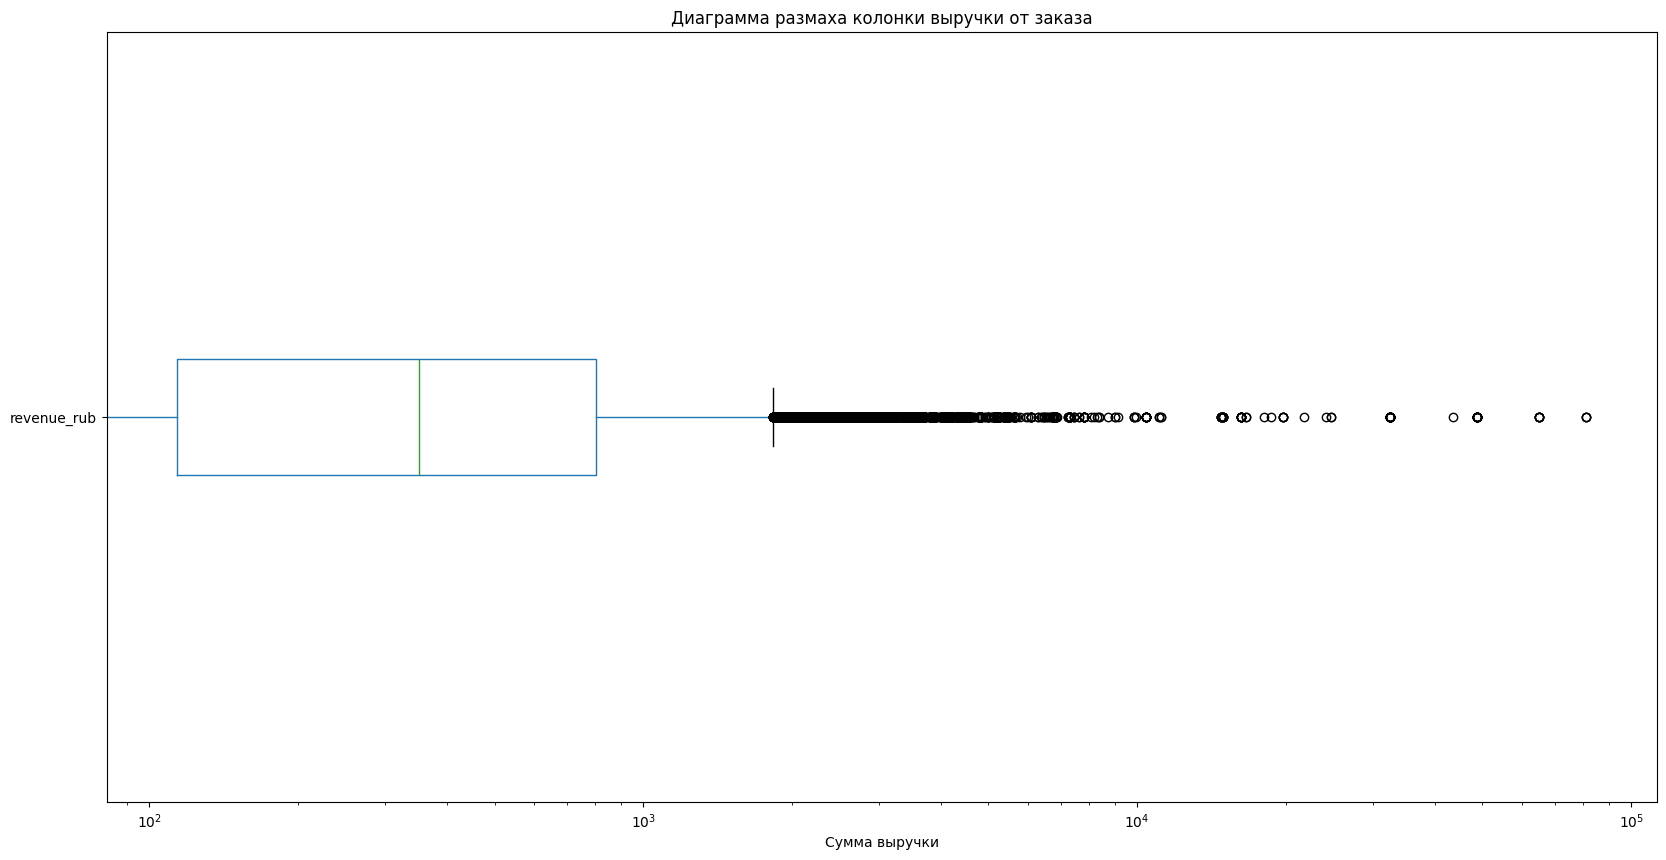

In [23]:
plt.figure(figsize=(20, 10))
boxplot = df.boxplot('revenue_rub', vert=False, grid=False)
boxplot.set_title('Диаграмма размаха колонки выручки от заказа')
boxplot.set_xlabel('Сумма выручки')
plt.xscale('log')
plt.show()

На диаграмме видно, что распределение выручки на заказ имеет сильный перекос вверх — есть заказы с экстремально высокими значениями (до $10^5$ рублей).
Основная масса значений сосредоточена в диапазоне $10^2–10^3$ рублей.

Необходима фильтрация выбросов, например, по 99-му перцентилю.

Также проверим данные на отрицательные значения. Возможно могут встречаться возвраты и их тоже следует исключить, чтобы не завышать количество валидных транзакций на пользователя

In [24]:
# Проверка отрицательной выручки
negative_revenue = df[df['revenue_rub'] < 0]
share_negative = len(negative_revenue) / len(df)

print(f'Количество отрицательных значений: {len(negative_revenue)}')
print(f'Доля отрицательных значений: {share_negative:.4%}')

Количество отрицательных значений: 381
Доля отрицательных значений: 0.1311%


In [25]:
# Удаляем возвраты (отрицательная выручка)
df = df[df['revenue_rub'] >= 0]

В данных были обнаружены отрицательные значения выручки, которые могут соответствовать возвратам.
Их доля составила 13%.

Поскольку такие значения искажают анализ пользовательских покупок, они были исключены из датасета.
Потери данных не являются критичными.

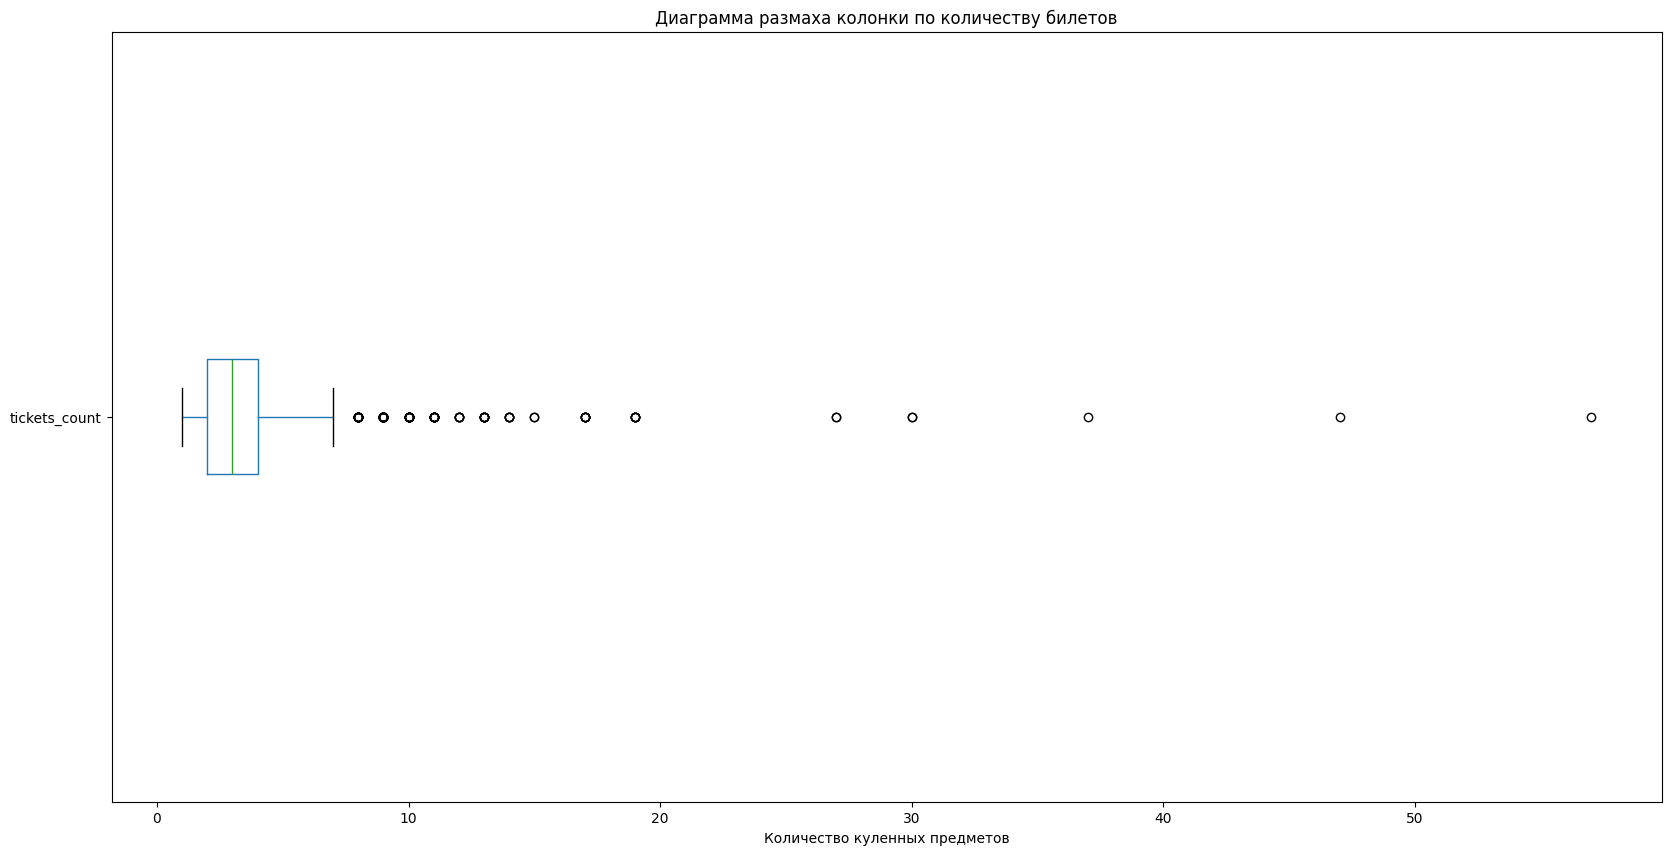

In [26]:
plt.figure(figsize=(20, 10))
boxplot = df.boxplot('tickets_count', vert=False, grid=False)
boxplot.set_title('Диаграмма размаха колонки по количеству билетов')
boxplot.set_xlabel('Количество куленных предметов')
plt.show()

Большинство заказов содержит до 10 билетов, медиана находится в районе 1–3 билетов.
Присутствуют выбросы до 40–50 билетов, но их количество относительно невелико.

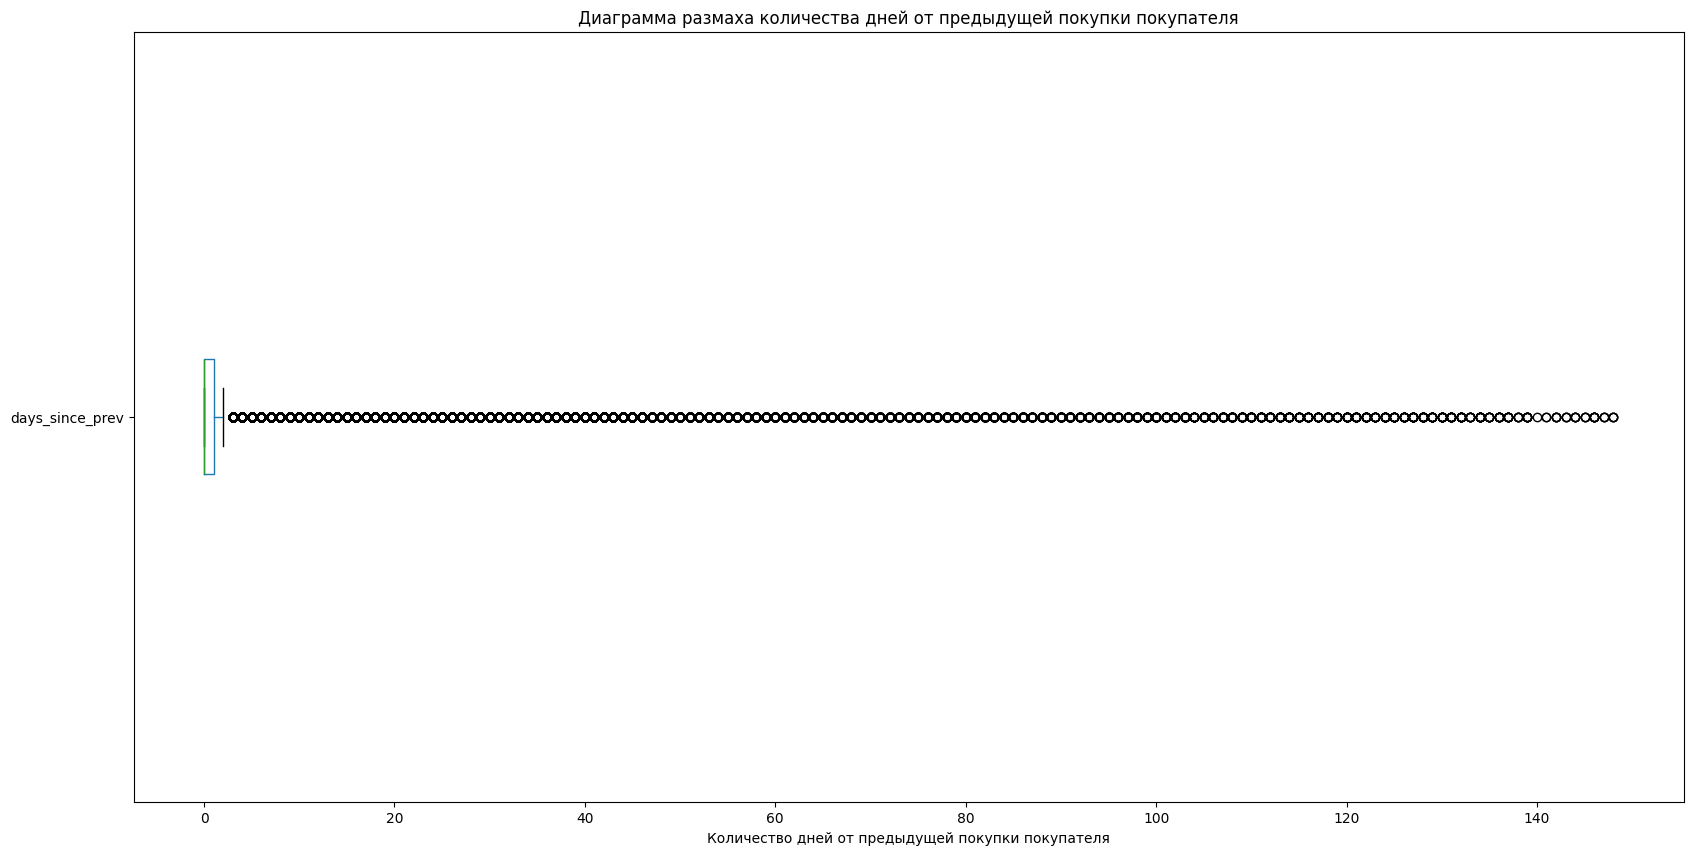

In [27]:
plt.figure(figsize=(20, 10))
boxplot = df.boxplot('days_since_prev', vert=False, grid=False)
boxplot.set_title('Диаграмма размаха количества дней от предыдущей покупки покупателя')
boxplot.set_xlabel('Количество дней от предыдущей покупки покупателя')
plt.show()

График показывает, что большинство покупателей совершают повторные покупки в течение 0–50 дней.
Есть длинный правый 'хвост' из редких покупок с большими интервалами .

Сделаем фильтрацию выбросов по 99 процентилю

In [28]:
df_filtered = df[df['revenue_rub'] <= df['revenue_rub'].quantile(0.99)]

Посмотрим, какой процент данных было отфильтровано, и сохраним датасет `df_filtered` в исходный датафрейм

In [29]:
(df.shape[0] - df_filtered.shape[0]) / df.shape[0]

0.00973513539591848

In [30]:
df = df_filtered.copy()

Посмотрим на результат сортировки

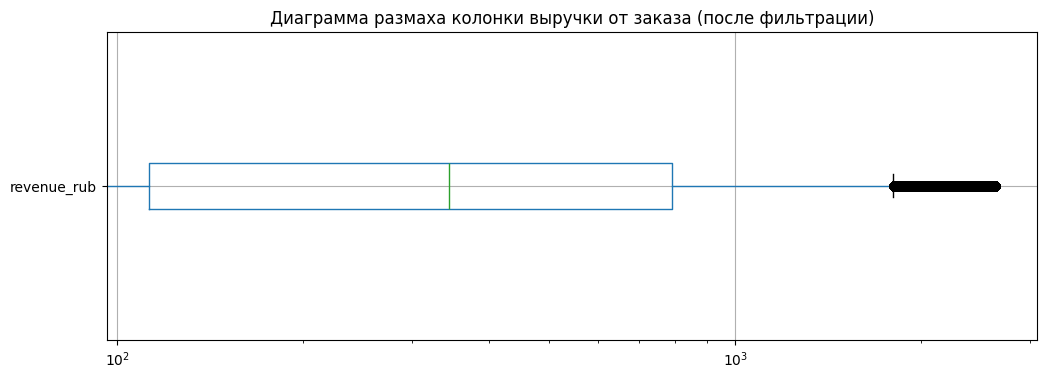

In [31]:
plt.figure(figsize=(12, 4))
df.boxplot('revenue_rub', vert=False)
plt.title('Диаграмма размаха колонки выручки от заказа (после фильтрации)')
plt.xscale('log')
plt.show()

Анализ распределения выручки показал наличие выраженной правосторонней асимметрии с экстремальными значениями, что характерно для транзакционных данных.

Для повышения устойчивости статистических оценок была применена фильтрация по 99-му перцентилю:

удалено менее 1% наблюдений;
устранены аномально крупные заказы;
распределение стало более репрезентативным для массового сегмента пользователей.

Следует отметить, что подобные выбросы могут соответствовать VIP-клиентам или корпоративным заказам, поэтому их исключение оправдано в рамках текущего анализа, но требует отдельного рассмотрения в будущем.

Данные приведены к аналитически корректному виду и готовы для дальнейшего исследования.

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

**Задача 3.1.** Постройте профиль пользователя — для каждого пользователя найдите:

- дату первого и последнего заказа;
- устройство, с которого был сделан первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (используйте поле `event_type_main`);
- общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.

После этого добавьте два бинарных признака:

- `is_two` — совершил ли пользователь 2 и более заказа;
- `is_five` — совершил ли пользователь 5 и более заказов.

**Рекомендация:** перед тем как строить профиль, отсортируйте данные по времени совершения заказа.

---


Следующая задача - построение профиля пользователя. Отсортируем данные по пользователю и времени совершения заказа, найдём необходимые метрики для профиля пользователя и построим два бинарных признака.

In [32]:
df = df.sort_values(by=['user_id','order_dt'])

Построим профиль пользователя.  Датасет будет содержать:

* дату первого и последнего заказа;
* устройство, с которого был сделан первый заказ;
* регион, в котором был сделан первый заказ;
* билетного партнёра, к которому обращались при первом заказе;
* жанр первого посещённого мероприятия;
* общее количество заказов;
* средняя выручка с одного заказа в рублях;
* среднее количество билетов в заказе;
* среднее время между заказами.

In [33]:
users_profile = df.groupby('user_id', as_index=False).agg({'order_dt': ['min', 'max'], 'order_id': 'count', 'revenue_rub': 'mean', 'tickets_count': 'mean'})
users_profile.columns = ['user_id', 'first_order', 'last_order', 'orders_count', 'avg_revenue_rub', 'avg_tickets_count'] 

first_orders = first_orders = (
    df.groupby('user_id')
      .agg({
          'device_type_canonical': 'first',
          'region_name': 'first',
          'service_name': 'first',
          'event_type_main': 'first'
      })
      .reset_index()
)

users_profile = users_profile.merge(first_orders, on='user_id', how='left')

a = df.groupby('user_id')['order_dt'].diff()
avg_table = a.groupby(df['user_id']).mean().reset_index()
avg_table.columns = ['user_id', 'avg_time_between_orders']
users_profile = users_profile.merge(avg_table, on='user_id')

total_users_profile = users_profile[['user_id', 'first_order', 
                                     'last_order', 'device_type_canonical', 
                                     'region_name', 'service_name', 
                                     'event_type_main', 'orders_count', 
                                     'avg_revenue_rub', 'avg_tickets_count', 
                                     'avg_time_between_orders']].copy()

Теперь добавим два бинарных признака:

* `is_two` — совершил ли пользователь 2 и более заказа;
* `is_five` — совершил ли пользователь 5 и более заказов.

In [34]:
total_users_profile['is_two'] = (total_users_profile['orders_count'] >= 2).astype('int')
total_users_profile['is_five'] = (total_users_profile['orders_count'] >= 5).astype('int')

Чтобы `avg_time_between_orders` было числом, выделим день из данных и посмотрим на конечный результат

In [35]:
total_users_profile['avg_time_between_orders'] = total_users_profile['avg_time_between_orders'].dt.days
total_users_profile

,user_id,first_order,last_order,device_type_canonical,region_name,service_name,event_type_main,orders_count,avg_revenue_rub,avg_tickets_count,avg_time_between_orders,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский_регион,край_билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский_регион,мой_билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская_область,лови_билет!,другое,3,767.213333,2.666667,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский_регион,край_билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский_край,лучшие_билеты,театр,2,61.310000,1.500000,16.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,fff13b79bd47d7c,2024-07-16,2024-10-31,mobile,каменевский_регион,мой_билет,другое,9,688.043333,2.555556,13.0,1,1
21834,fff32fc9ad0f9f6,2024-08-15,2024-10-28,desktop,каменевский_регион,билеты_без_проблем,стендап,2,850.995000,2.500000,74.0,1,0
21835,fffcd3dde79eb2c,2024-06-20,2024-10-30,desktop,каменевский_регион,билеты_без_проблем,концерты,33,557.908485,2.787879,4.0,1,1
21836,fffeeb3c120cf0b,2024-09-24,2024-09-24,desktop,широковская_область,билеты_без_проблем,стендап,1,661.530000,2.000000,NaN,0,0


In [36]:
print(total_users_profile.duplicated('user_id').sum())

0


В результате агрегации сформирован профиль пользователя, включающий ключевые поведенческие, финансовые и контекстные характеристики.

Добавлены бинарные признаки (is_two, is_five), позволяющие сегментировать пользователей по уровню вовлечённости.

Дубликаты пользователей отсутствуют, что подтверждает корректность агрегации.

---

**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными вы работаете: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитайте:

- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов.

Также изучите статистические показатели:

- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.

По результатам оцените данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количестве билетов?

Если вы найдёте аномальные значения, опишите их и примите обоснованное решение о том, как с ними поступить:

- Оставить и учитывать их при анализе?
- Отфильтровать данные по какому-то значению, например, по 95-му или 99-му перцентилю?

Если вы проведёте фильтрацию, то вычислите объём отфильтрованных данных и выведите статистические показатели по обновлённому датасету.

В прошлом шаге мы выяснили, что в количестве пользователей нет дубликатов. Посмотрим на количество пользователей в выборке с помощью `shape`:

In [37]:
total_users_profile.shape[0]

21838

В выборке представлено 21 854 пользователя. Объём данных достаточен для проведения анализа и получения статистически значимых выводов.

1. Средняя выручка с одного заказа:

In [38]:
total_users_profile['avg_revenue_rub'].mean()

np.float64(545.0286829734993)

Средняя выручка с одного заказа составляет 544.39 рубля, что выглядит реалистично для данного типа сервиса.

2. Доля пользователей, совершивших 2 и более заказа:

In [39]:
total_users_profile['is_two'].value_counts(normalize=True)

is_two
1    0.617044
0    0.382956
Name: proportion, dtype: float64

3. Доля пользователей, совершивших 5 и более заказов:

In [40]:
total_users_profile['is_five'].value_counts(normalize=True)

is_five
0    0.710138
1    0.289862
Name: proportion, dtype: float64

Доля пользователей, совершивших более одного заказа, превышает долю пользователей с одной покупкой, что говорит о наличии повторных клиентов. При этом доля пользователей с 5 и более заказами существенно ниже, что соответствует ожидаемому поведению: лишь небольшая часть аудитории становится активно лояльной.

Далее изучим статистические показатели колонок.

1. Общее число заказов

In [41]:
total_users_profile['orders_count'].describe(percentiles=(i for i in np.arange(0,1, 0.01)))

count    21838.000000
mean        13.158760
std        121.562817
min          1.000000
0%           1.000000
             ...     
96%         41.000000
97%         54.000000
98%         79.000000
99%        152.000000
max      10168.000000
Name: orders_count, Length: 105, dtype: float64

Распределение количества заказов сильно скошено вправо.
Медианное значение существенно ниже среднего, что указывает на наличие выбросов.

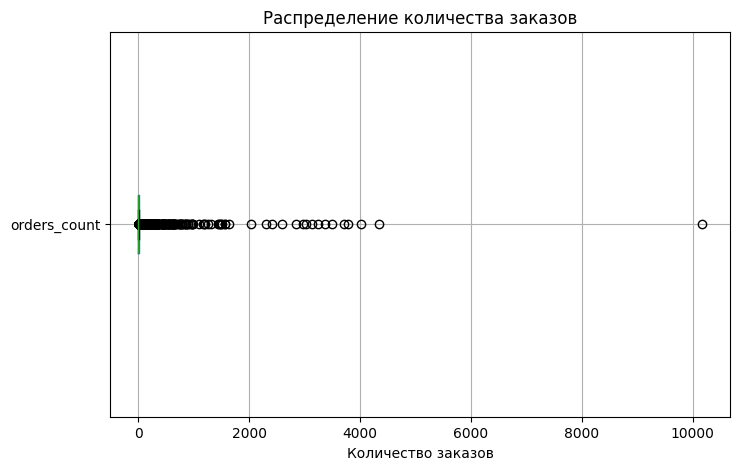

In [42]:
plt.figure(figsize=(8,5))
total_users_profile.boxplot('orders_count', vert=False)
plt.title('Распределение количества заказов')
plt.xlabel('Количество заказов')
plt.show()

Большинство пользователей совершают небольшое число заказов (1–5), однако присутствуют экстремальные значения (например, более 10 000 заказов), которые явно являются аномальными и могут искажать результаты анализа.

2. Среднее число билетов в заказе

In [43]:
total_users_profile['avg_tickets_count'].describe(percentiles=(i for i in np.arange(0,1, 0.01)))

count    21838.000000
mean         2.744063
std          0.913068
min          1.000000
0%           1.000000
             ...     
96%          4.333333
97%          5.000000
98%          5.000000
99%          5.000000
max         11.000000
Name: avg_tickets_count, Length: 105, dtype: float64

Медиана билетов в заказе примерно совпадает со средни, и составляет 2.75, что говорит о возможной симметричности распределения. Стандертное отклоение - 0.91. 99 процетов значений расположены от 1 до 5 билетов, при максимальном значении 11 билетов. Посмотрим на гистрограмму и диаграмму размаха avg_tickets_count:

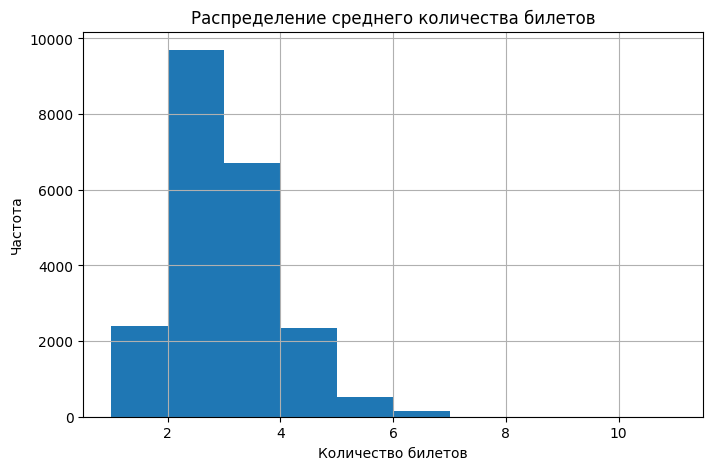

In [44]:
plt.figure(figsize=(8,5))
total_users_profile['avg_tickets_count'].hist(bins=10)
plt.title('Распределение среднего количества билетов')
plt.xlabel('Количество билетов')
plt.ylabel('Частота')
plt.show()

Распределение близко к нормальному, но имеет правостороннюю асимметрию.
Основная масса значений сосредоточена в диапазоне 1–5 билетов на заказ.

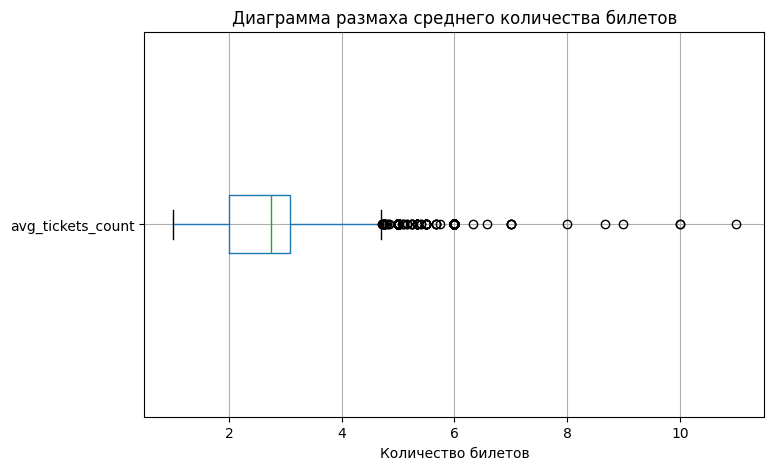

In [45]:
plt.figure(figsize=(8,5))
total_users_profile.boxplot('avg_tickets_count', vert=False)
plt.title('Диаграмма размаха среднего количества билетов')
plt.xlabel('Количество билетов')
plt.show()

Выбросы присутствуют, но их немного, и они не оказывают значительного влияния на общую картину.

3. Среднее количество дней между покупками.

In [46]:
total_users_profile['avg_time_between_orders'].describe(percentiles=(i for i in np.arange
                                                                     (0,1, 0.01)))

count    13475.000000
mean        15.648015
std         22.337706
min          0.000000
0%           0.000000
             ...     
96%         68.000000
97%         78.000000
98%         94.000000
99%        112.000000
max        148.000000
Name: avg_time_between_orders, Length: 105, dtype: float64

Распределение имеет выраженную правостороннюю асимметрию.
Среднее значение заметно превышает медиану, что говорит о наличии пользователей с большими интервалами между покупками.

Посмотрим диаграмму размаха `avg_time_between_orders`:

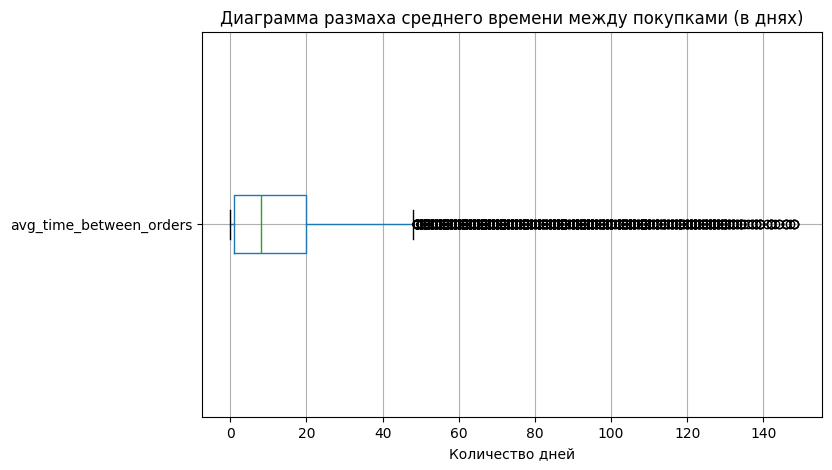

In [47]:
plt.figure(figsize=(8,5))
total_users_profile.boxplot('avg_time_between_orders', vert=False)
plt.title('Диаграмма размаха среднего времени между покупками (в днях)')
plt.xlabel('Количество дней')
plt.show()

Основная масса пользователей совершает повторные покупки в относительно короткие сроки.

На основании анализа было принято решение удалить экстремальные значения в количестве заказов, так как они существенно искажают распределение.

In [48]:
# фильтрация по 99 перцентилю
upper_bound = total_users_profile['orders_count'].quantile(0.99)

total_users_profile_filtered = total_users_profile[
    total_users_profile['orders_count'] <= upper_bound
]

In [49]:
for i in ['orders_count', 'avg_tickets_count', 'avg_time_between_orders']:
    print(total_users_profile_filtered[i].describe())
    print( )

count    21622.000000
mean         6.495606
std         14.308033
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        152.000000
Name: orders_count, dtype: float64

count    21622.000000
mean         2.744257
std          0.917477
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         11.000000
Name: avg_tickets_count, dtype: float64

count    13259.000000
mean        15.902934
std         22.428734
min          0.000000
25%          1.000000
50%          8.000000
75%         21.000000
max        148.000000
Name: avg_time_between_orders, dtype: float64



В выборке представлено 21 854 уникальных пользователя, что является достаточным объёмом для проведения статистически значимого анализа.

Ключевые характеристики:

* средний чек составляет около 544 руб., что соответствует ожиданиям для билетного сервиса;
* распределение количества заказов имеет выраженную правостороннюю асимметрию — большинство пользователей совершают 1–3 покупки;
* доля пользователей с высокой активностью (5 и более заказов) существенно ниже, что отражает типичную структуру клиентской базы (long-tail распределение).

Обнаружены аномальные значения — пользователи с экстремально высоким количеством заказов (более 10 000), которые могут быть связаны с техническими особенностями или корпоративными аккаунтами.

После фильтрации по 99-му перцентилю:

* удалено менее 1% наблюдений;
* распределения стали более устойчивыми;
* снижено влияние экстремальных значений на агрегированные метрики.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

---

**Задача 4.1.1.** Изучите распределение пользователей по признакам.

- Сгруппируйте пользователей:
    - по типу их первого мероприятия;
    - по типу устройства, с которого совершена первая покупка;
    - по региону проведения мероприятия из первого заказа;
    - по билетному оператору, продавшему билеты на первый заказ.
- Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.
- Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?

---


Сформулируем гипотезы для задания: 

Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

В этом блоке задания исследуем признаки, которые описывают первый заказ пользователя. С помощью группировки мы посмотрим на количество и доли пользователей:
 * по типу их первого мероприятия
 * по типу устройства, с которого совершена первая покупка;
 * по региону проведения мероприятия из первого заказа;
 * по билетному оператору, продавшему билеты на первый заказ.

Следующим шагом мы построим столбчатые диаграмм и сделаем промежуточные выводы по результату.

Первым делом напишем функцию для построение графиков.

Первым шагом будет создание параметров для построения графиков: название заголовков, названия по оси x и у.

Вторым шагом будет группировка данных по необходимым признакам и вычисление необходимых параметров для визуализации.

Финальным шагом будет построение столбчатых диаграмм с передачей всех необходимых параметров.

In [50]:
def create_bars(col):
    title_1 = {
        'event_type_main': 'Группировка пользователей по типу их первого мероприятия',
        'device_type_canonical': 'Группировка пользователей по типу устройства',
        'region_name': 'Группировка пользователей по региону проведения мероприятия',
        'service_name': 'Группировка пользователей по билетному оператору'
    }

    title_2 = {
        'event_type_main': 'Группировка пользователей по типу их первого мероприятия в долях',
        'device_type_canonical': 'Группировка пользователей по типу устройства в долях',
        'region_name': 'Группировка пользователей по региону проведения мероприятия в долях',
        'service_name': 'Группировка пользователей по билетному оператору в долях'
    }

    xlabel = {
        'event_type_main': 'Типы мероприятий',
        'device_type_canonical': 'Типы устройства',
        'region_name': 'Регионы',
        'service_name': 'Билетные операторы'
    }

    info = total_users_profile_filtered.groupby(col)['user_id'].count()
    data = pd.DataFrame({'col': info.index, 'val': info.values})
    data['per'] = round((data['val'] / sum(data['val'])) * 100, 3)

    data_val = data.sort_values(by='val', ascending=False)
    
    data_val.plot(
        kind='bar',
        x='col',
        y='val',
        title=title_1[col],
        xlabel=xlabel[col],
        ylabel='Количество',
        legend=False,
        color='steelblue',
        figsize=(12,6)
    )

    data_per = data.sort_values(by='per', ascending=False)
    
    data_per.plot(
        kind='bar',
        x='col',
        y='per',
        title=title_2[col],
        xlabel=xlabel[col],
        ylabel='Доли',
        legend=False,
        color='steelblue',
        figsize=(12, 6)
    )

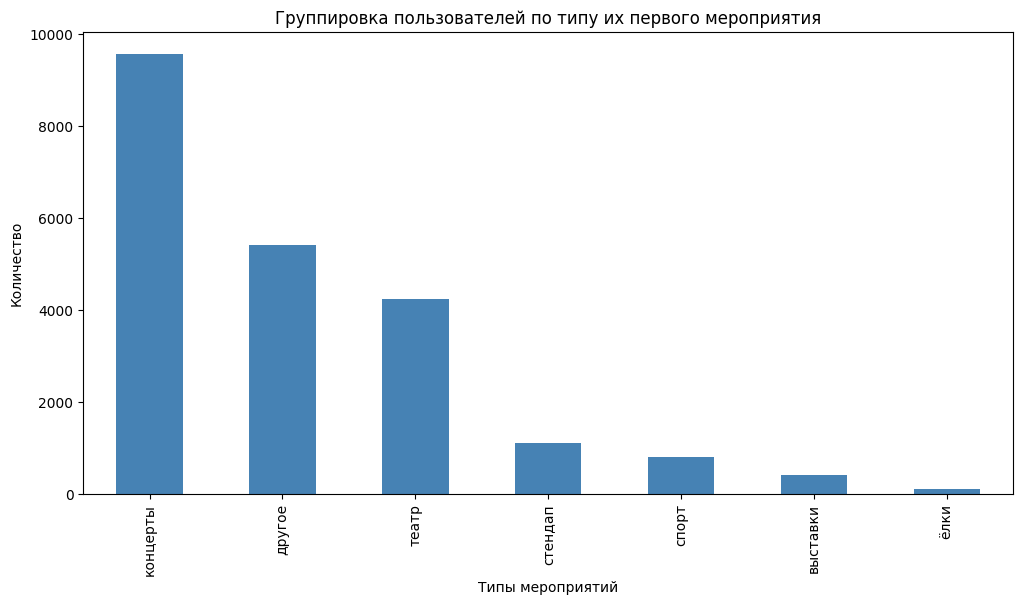

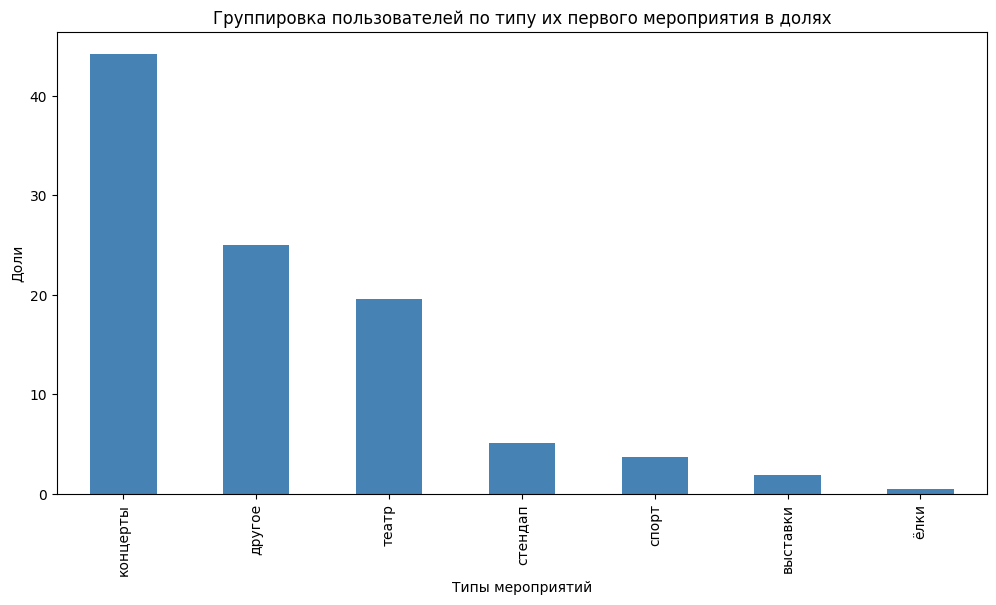

In [51]:
create_bars('event_type_main')

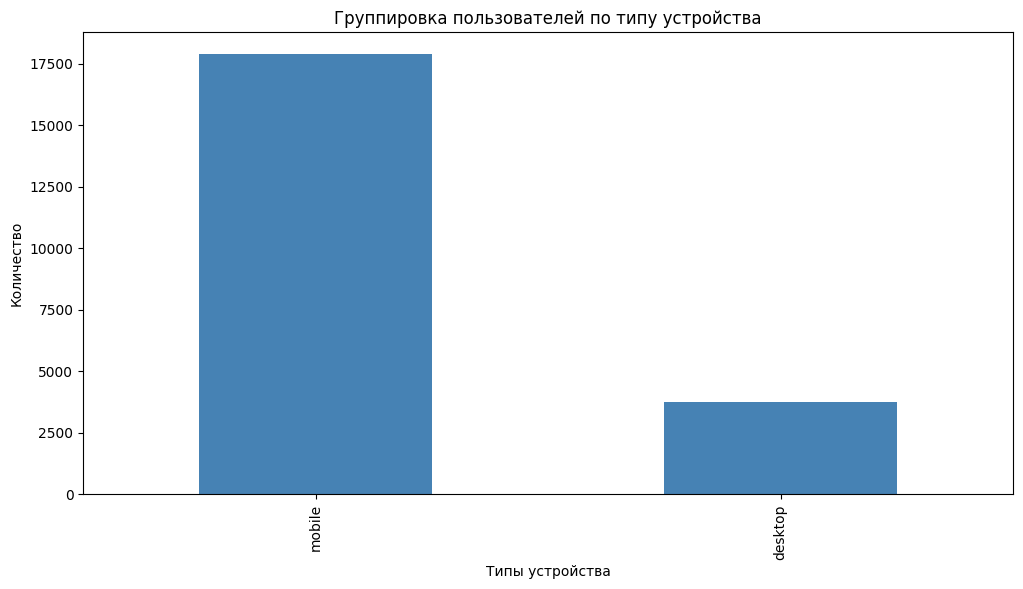

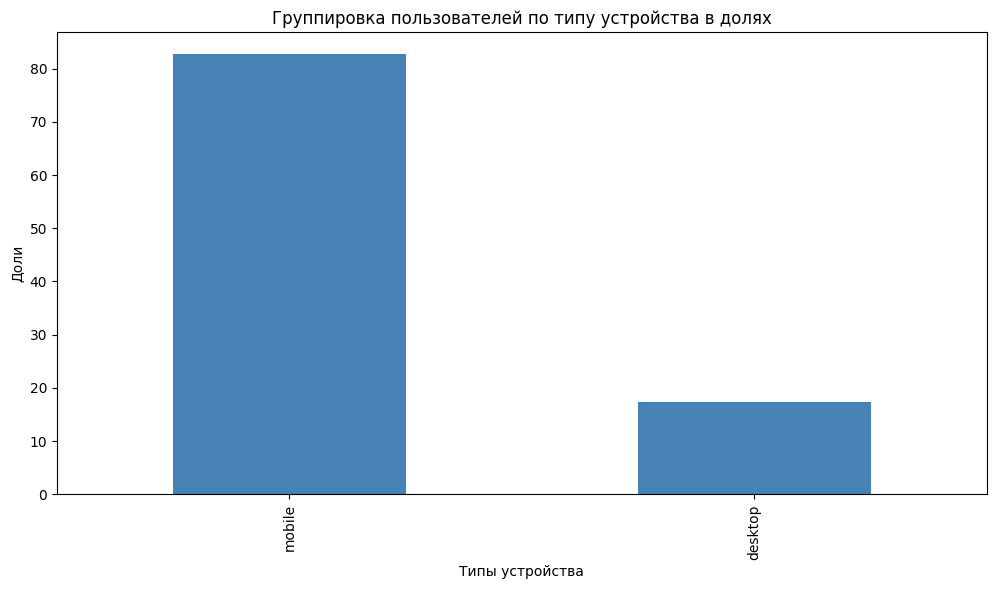

In [52]:
create_bars('device_type_canonical')

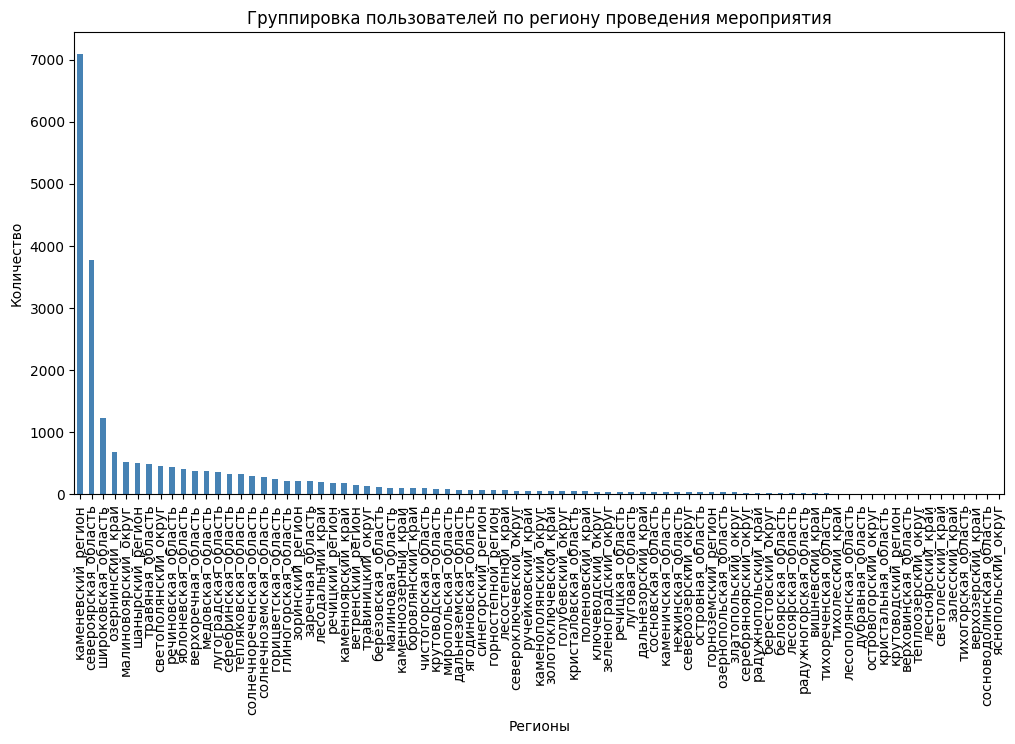

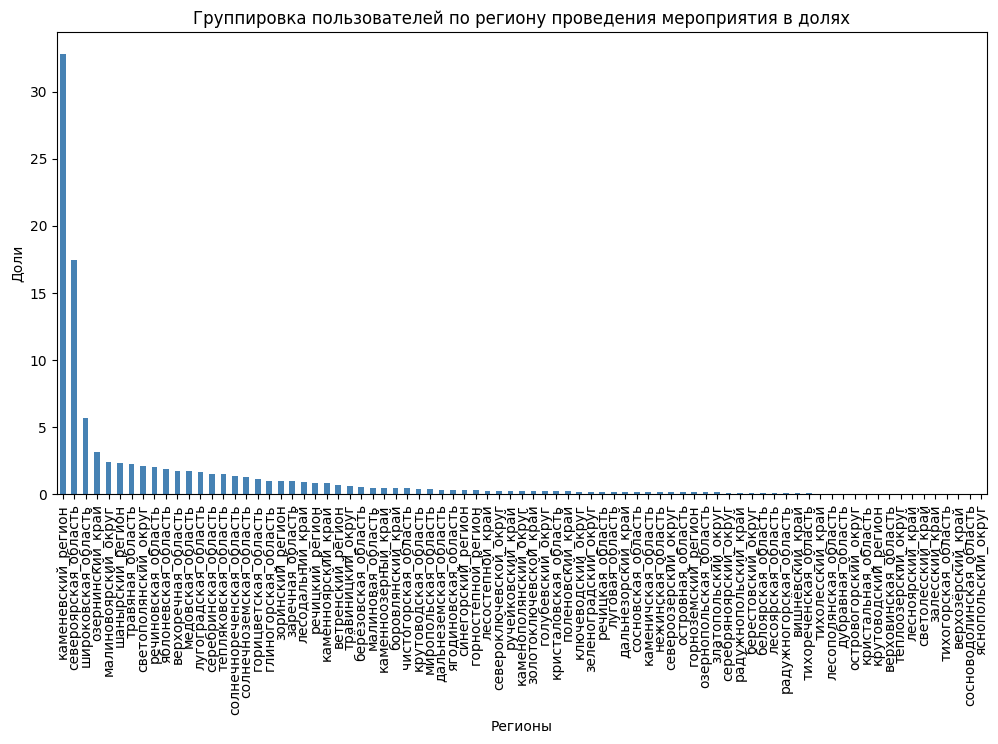

In [53]:
create_bars('region_name')

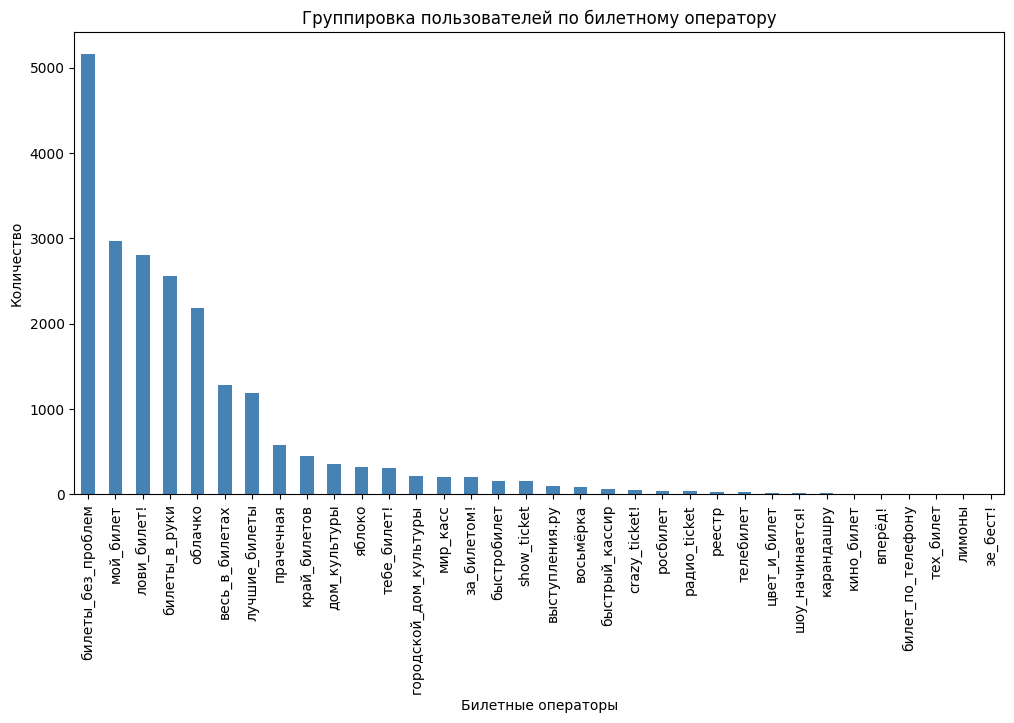

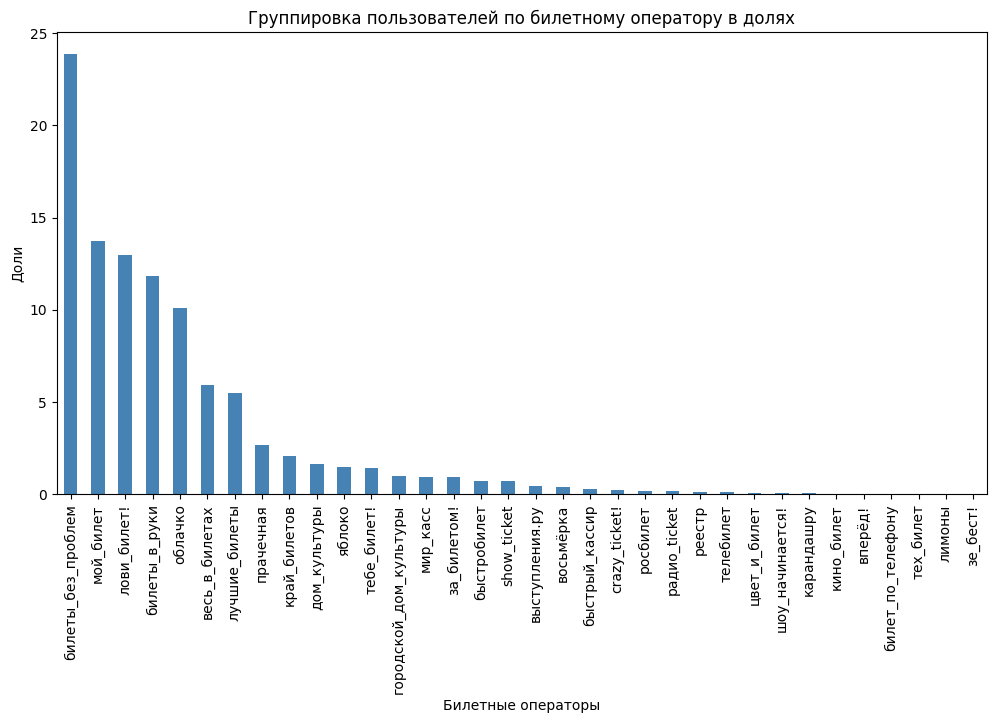

In [54]:
create_bars('service_name')

Распределение пользователей по сегментам является неравномерным, что указывает на наличие выраженных каналов привлечения и предпочтений пользователей.

Основные наблюдения:

* доминирующий тип мероприятия — концерты (более 40%);
* основной канал взаимодействия — мобильные устройства (более 80%);
* наблюдается концентрация пользователей в отдельных регионах;
* рынок билетных операторов фрагментирован, но выделяются несколько лидеров.

Существуют выраженные «точки входа» в продукт, через которые проходит основная масса пользователей. Эти сегменты являются ключевыми для привлечения и требуют приоритетного внимания.

---

**Задача 4.1.2.** Проанализируйте возвраты пользователей:

- Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
- Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.
- Ответьте на вопросы:
    - Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
    - Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

---


Теперь проанализируем возврат пользователей. Посчитаем для каждого сегмента долю пользователей, совершивших 2 и более заказа, а также визуализируем это на графике.

Нашем функцию.

Первым шагом будет создание параметров для построения графиков: название заголовков, названия по оси x и у.

Вторым шагом будет группировка данных по необходимым признакам и вычисление необходимых параметров для визуализации.

Финальным шагом будет построение столбчатых диаграмм с передачей всех необходимых параметров.



In [55]:
def create_conversion_bars(col):
    title = {
        'event_type_main': 'Доля пользователей с 2+ заказами по типу первого мероприятия',
        'device_type_canonical': 'Доля пользователей с 2+ заказами по типу устройства',
        'region_name': 'Доля пользователей с 2+ заказами по регионам',
        'service_name': 'Доля пользователей с 2+ заказами по билетным операторам'
    }

    xlabel = {
        'event_type_main': 'Типы мероприятий',
        'device_type_canonical': 'Типы устройства',
        'region_name': 'Регионы',
        'service_name': 'Билетные операторы'
    }

    # агрегация
    data = total_users_profile_filtered.groupby(col).agg(
        users=('user_id', 'count'),
        converted=('is_two', 'sum')
    ).reset_index()

    data['share'] = round(data['converted'] / data['users'] * 100, 3)

    # топ-10 для длинных сегментов
    if col in ['region_name', 'service_name']:
        data = data.sort_values('users', ascending=False).head(10)

    data = data.sort_values('share', ascending=False)

    # график
    data.plot(
        kind='bar',
        x=col,
        y='share',
        title=title[col],
        xlabel=xlabel[col],
        ylabel='Доля пользователей с 2+ заказами (%)',
        legend=False,
        figsize=(12, 6),
        color='steelblue'
    )

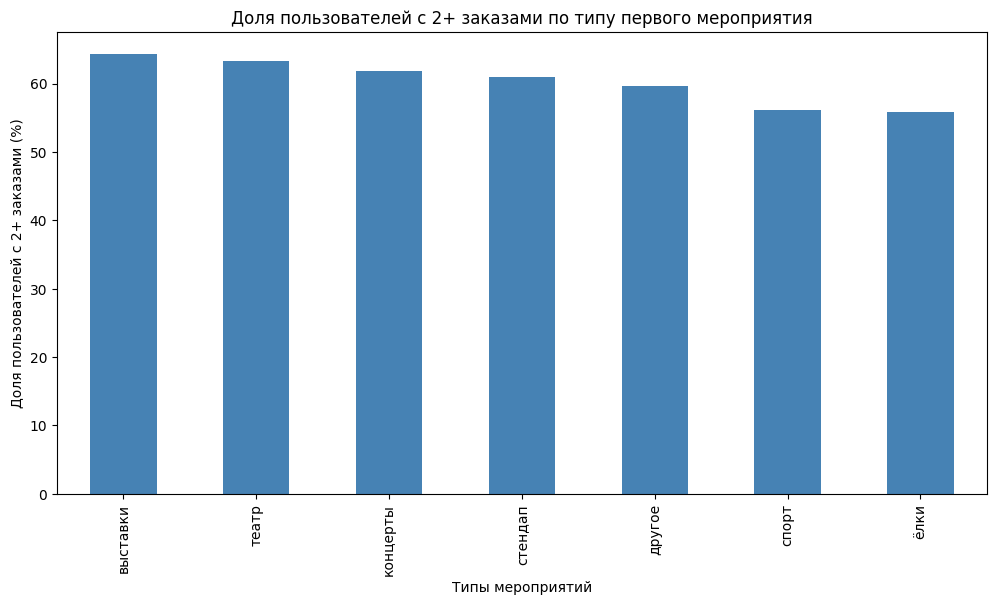

In [56]:
create_conversion_bars('event_type_main')

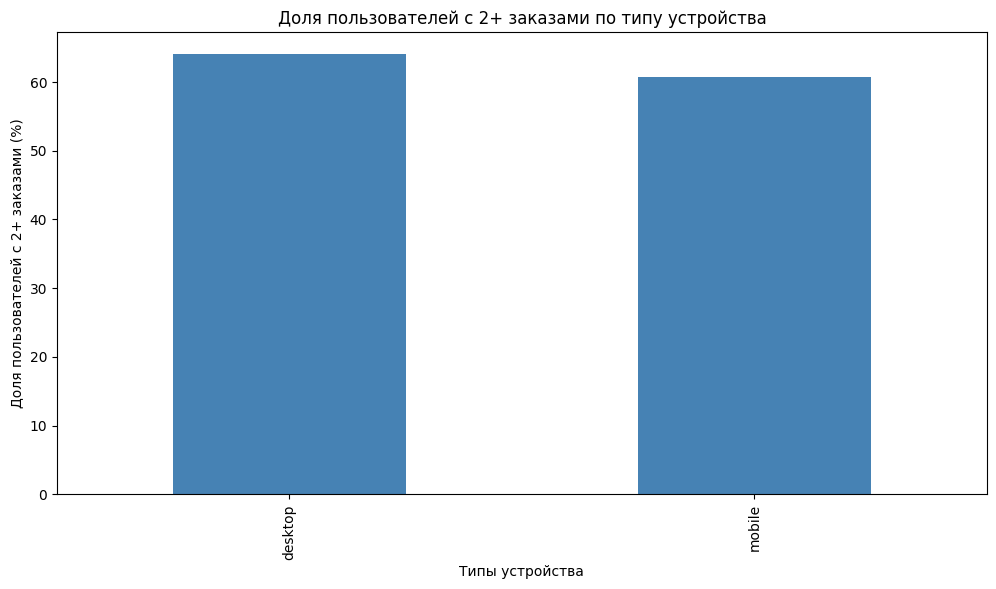

In [57]:
create_conversion_bars('device_type_canonical')

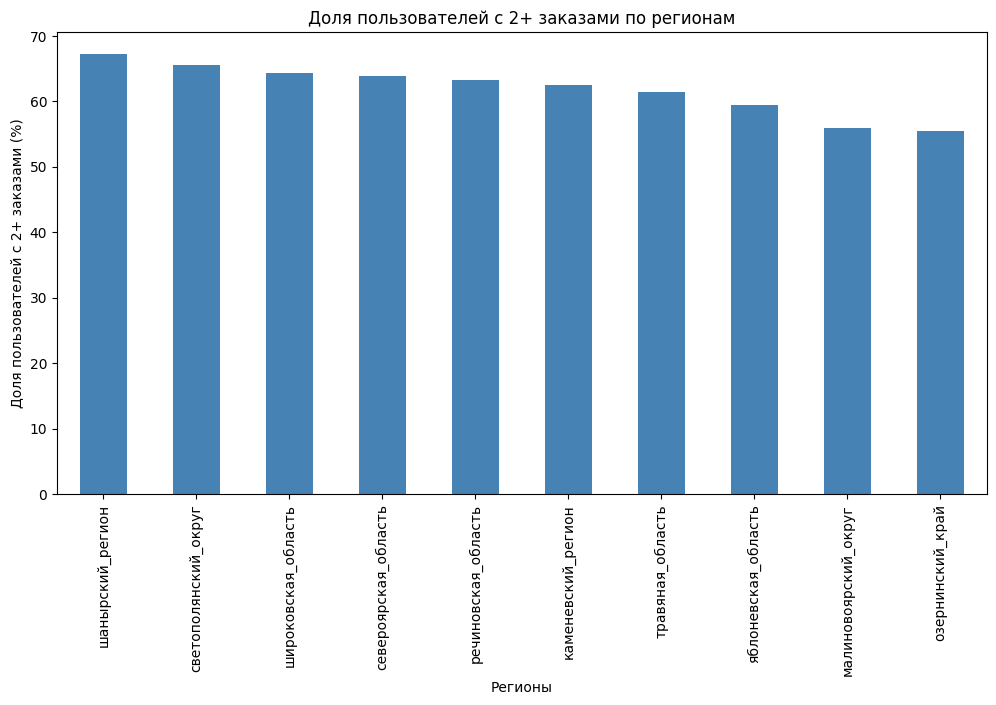

In [58]:
create_conversion_bars('region_name')

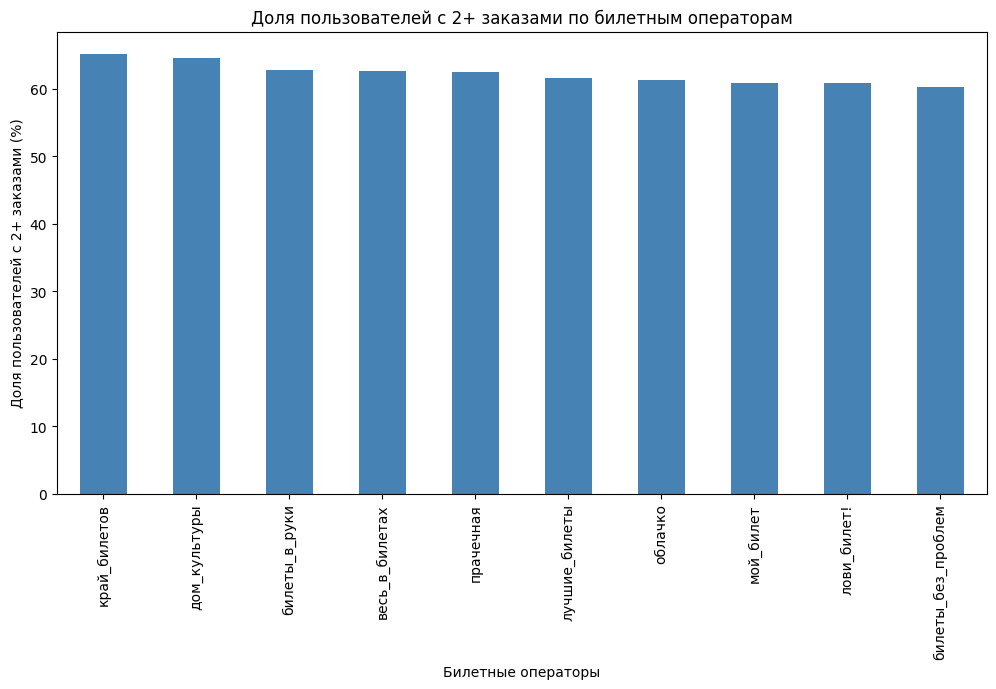

In [59]:
create_conversion_bars('service_name')

In [60]:
avg_share = round(
    total_users_profile_filtered['is_two'].mean() * 100, 3
)
print(f'Средняя доля пользователей с 2+ заказами: {avg_share}%')

Средняя доля пользователей с 2+ заказами: 61.322%


В среднем по выборке доля пользователей, совершивших 2 и более заказа, составляет 61.322%.

Можно заметить, что доля возвратов различается между сегментами. Например, среди пользователей, совершивших первый заказ на выставки и театры, доля повторных заказов превышает 60% и находится на уровне или выше среднего по выборке. Концерты и спортивные мероприятия также демонстрируют значения, близкие к среднему, и существенных различий между ними не наблюдается.

По типу устройства различия менее выражены: пользователи с ноутбуков демонстрируют немного более высокую долю возвратов по сравнению с мобильными устройствами, однако разница незначительна.

При анализе регионов видно, что в некоторых менее крупных сегментах наблюдаются более высокие значения доли повторных заказов. Однако такие результаты следует интерпретировать с осторожностью, поскольку малый размер сегмента может приводить к нестабильным оценкам.

В целом можно сделать вывод, что различия между сегментами присутствуют, однако в большинстве случаев они не являются существенными.

---

**Задача 4.1.3.** Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

Гипотеза 1:
Тип мероприятия влияет на вероятность возврата пользователей.

Средняя доля пользователей, совершивших 2 и более заказа, составляет 61.322%. При сравнении сегментов видно, что значения для концертов и спортивных мероприятий находятся на уровне среднего или незначительно отличаются от него. Существенного превышения среднего значения ни в одном из сегментов не наблюдается.

Вывод: гипотеза не подтверждается — тип мероприятия не оказывает заметного влияния на вероятность возврата пользователей.

Гипотеза 2:
В регионах с наибольшим числом пользователей выше доля повторных заказов.

Анализ показывает, что регионы с наибольшим количеством пользователей имеют долю возвратов, близкую к среднему значению (61.322%) и не демонстрируют устойчивого превышения этого уровня. При этом в некоторых менее крупных регионах доля возвратов может быть выше среднего, однако такие результаты могут быть связаны с малым размером сегмента и не являются надёжными.

Вывод: гипотеза не подтверждается — высокая численность пользователей в регионе не связана с более высокой вероятностью возврата.


---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**Задача 4.2.1.** Проследите связь между средней выручкой сервиса с заказа и повторными заказами.

- Постройте сравнительные гистограммы распределения средней выручки с билета (`avg_revenue_rub`):
    - для пользователей, совершивших один заказ;
    - для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы:
    - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
    - Есть ли различия между группами?

Текст на сером фоне:
    
**Рекомендация:**

1. Используйте одинаковые интервалы (`bins`) и прозрачность (`alpha`), чтобы визуально сопоставить распределения.
2. Задайте параметру `density` значение `True`, чтобы сравнивать форму распределений, даже если число пользователей в группах отличается.

---


Далее построим сравнительные гистограммы распределения средней выручки билета

* для пользователей, совершивших один заказ;
* для вернувшихся пользователей, совершивших 2 и более заказа.

А также ответим, В каких диапазонах средней выручки концентрируются пользователи из каждой группы и есть ли различия между ними

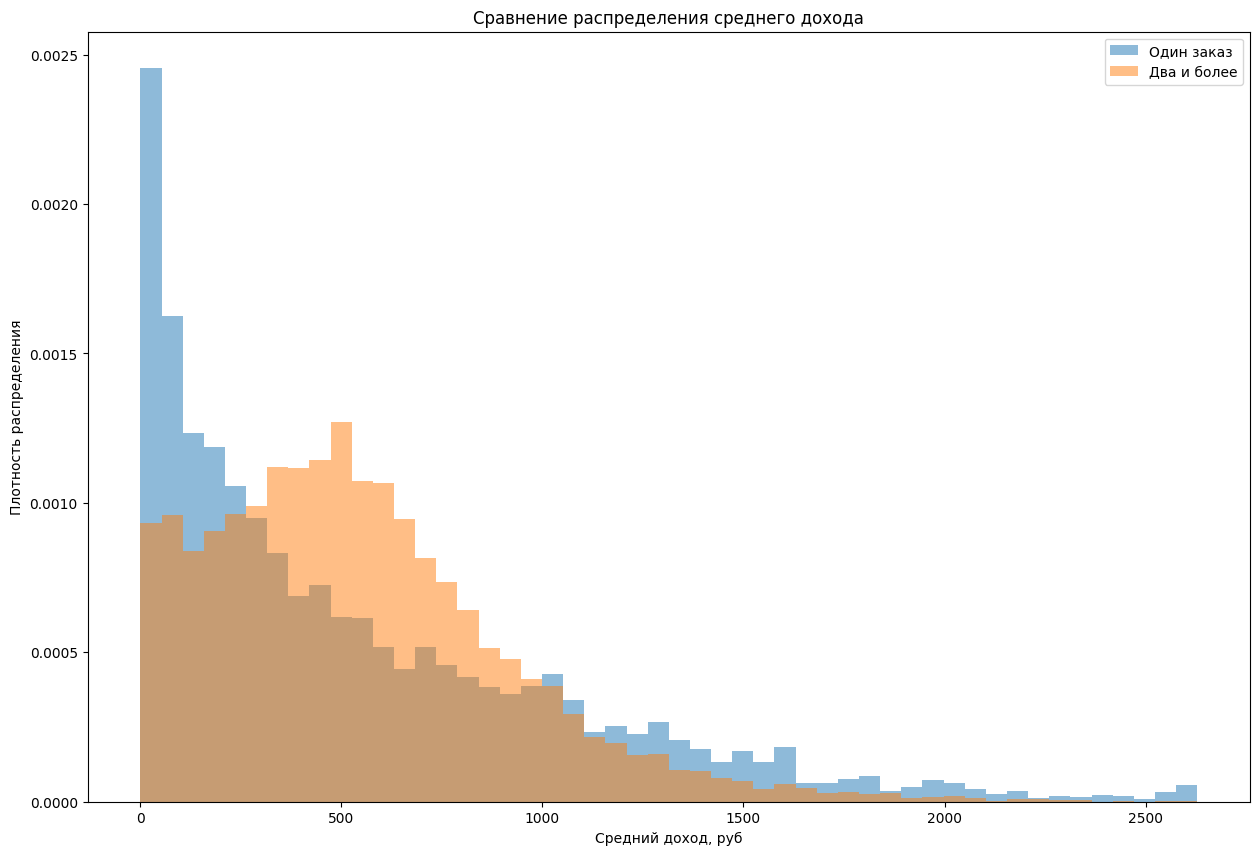

In [61]:
non_active_users = total_users_profile_filtered[total_users_profile_filtered['is_two'] == 0]['avg_revenue_rub']
active_users = total_users_profile_filtered[total_users_profile_filtered['is_two'] == 1]['avg_revenue_rub']


plt.figure(figsize=(15,10))
non_active_users.plot.hist(bins=50, alpha=0.5, density=True, label='Один заказ')
active_users.plot.hist(bins=50, alpha=0.5, density=True, label='Два и более')
plt.xlabel('Средний доход, руб')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения среднего дохода')
plt.legend()
plt.show()

Плотность средней выручки для пользователей с одним заказом сконцентрированно околонулевых значений. Посмотрим, какие минимальные значения у этих двух групп:

In [62]:
print(total_users_profile_filtered[total_users_profile_filtered['is_two'] == 0]['avg_revenue_rub'].min())
print(total_users_profile_filtered[total_users_profile_filtered['is_two'] == 1]['avg_revenue_rub'].min())

0.0
0.0


Данные содержат отрицательные значения. Возможно это данные с возвратом билетов. Попробуем отфильтровать данные, чтобы значения среднего дохода были неторицательными и визуализируем результат:

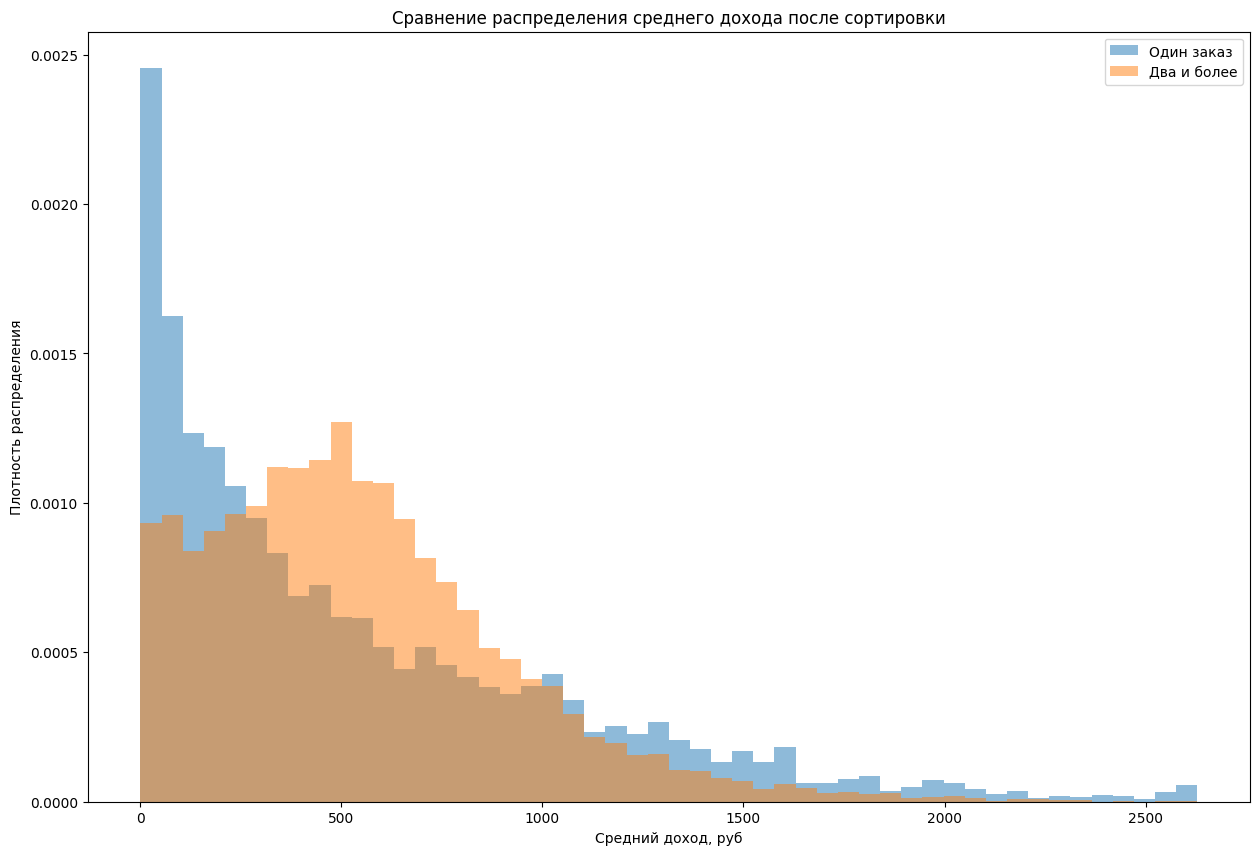

In [63]:
non_active_users = total_users_profile_filtered[(total_users_profile_filtered['is_two'] == 0) & (total_users_profile_filtered['avg_revenue_rub'] >= 0)]['avg_revenue_rub']
active_users = total_users_profile_filtered[(total_users_profile_filtered['is_two'] == 1) & (total_users_profile_filtered['avg_revenue_rub'] >= 0)]['avg_revenue_rub']


plt.figure(figsize=(15,10))
non_active_users.plot.hist(bins=50, alpha=0.5, density=True, label='Один заказ')
active_users.plot.hist(bins=50, alpha=0.5, density=True, label='Два и более')
plt.xlabel('Средний доход, руб')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения среднего дохода после сортировки')
plt.legend()
plt.show()

Распределение средней выручки у пользователей, совершивших только один заказ, имеет выраженный пик в области низких значений, близких к нулю. Это говорит о том, что значительная часть таких пользователей совершает покупки с низкой выручкой.

В группе пользователей, совершивших два и более заказа, распределение смещено вправо: основная масса значений сосредоточена в диапазоне около 400–600 рублей. При этом доля пользователей с очень низкой выручкой в этой группе ниже.

В данных присутствовали отрицательные значения выручки, которые могут быть связаны с возвратами. Их доля оказалась незначительной, поэтому их исключение не оказало существенного влияния на форму распределения.

После очистки данных основные закономерности сохранились: пользователи с одним заказом по-прежнему концентрируются в области низких значений средней выручки, тогда как у вернувшихся пользователей распределение смещено в сторону более высоких значений.

---

**Задача 4.2.2.** Сравните распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

---


Визуализируем распределение по средней выручке с заказа для пользователей, совершивших от 2 до 4 заказов и более 5 заказов, с целью понять, если ли различие средней выручки у этих двух групп

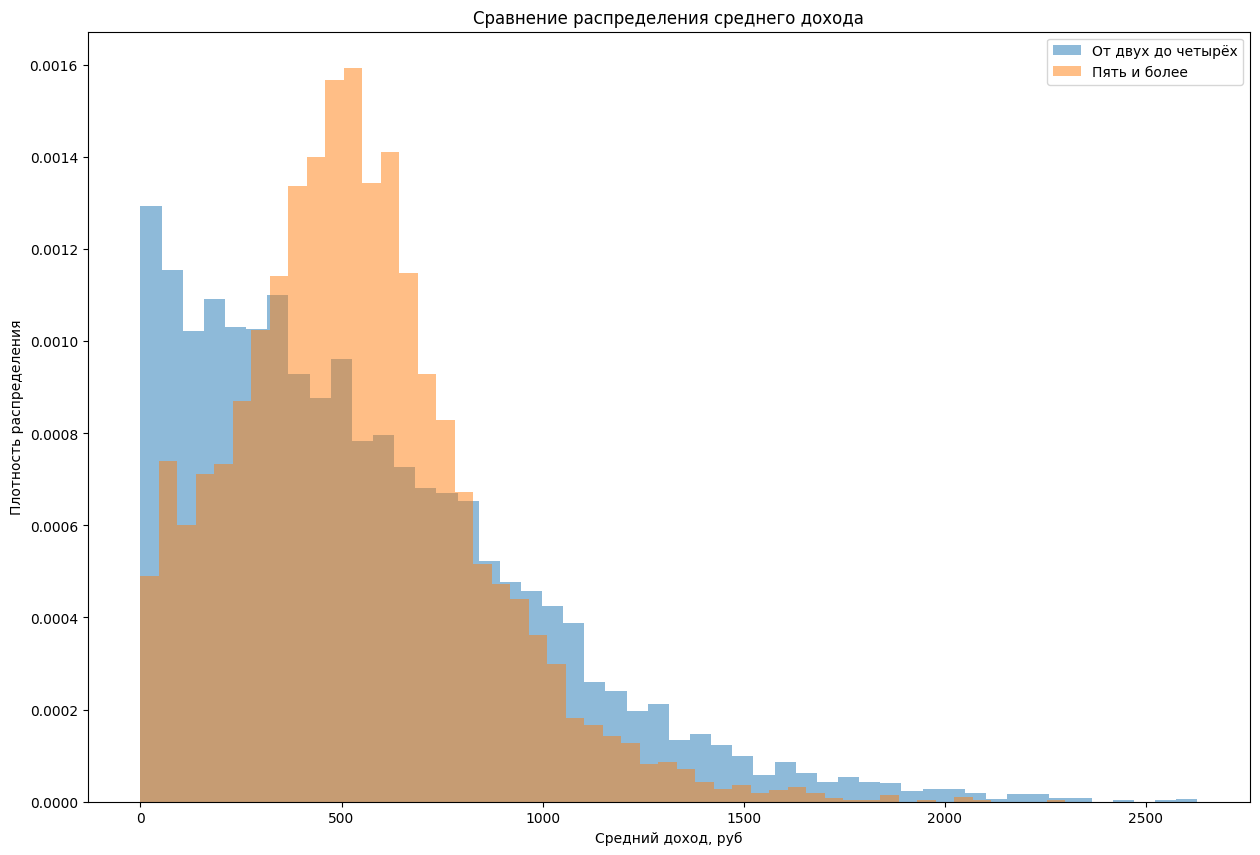

In [64]:
medium_active_users = total_users_profile_filtered[(total_users_profile_filtered['orders_count'] >= 2) 
& (total_users_profile_filtered['orders_count'] <= 4)]['avg_revenue_rub']
super_active_users = total_users_profile_filtered[total_users_profile_filtered['is_five'] == 1]['avg_revenue_rub']


plt.figure(figsize=(15,10))
medium_active_users.plot.hist(bins=50, alpha=0.5, density=True, label='От двух до четырёх')
super_active_users.plot.hist(bins=50, alpha=0.5, density=True, label='Пять и более')
plt.xlabel('Средний доход, руб')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения среднего дохода')
plt.legend()
plt.show()

В группе пользователей, совершивших 5 и более заказов, медианное значение средней выручки с заказа выше, чем в группе с 2–4 заказами.

Кроме того, в группе «5 и более» наблюдается больший разброс значений (более длинный «ящик» и усы), а также присутствуют выбросы вверх.

В группе «2–4 заказа» распределение более компактное и сосредоточено в более низком диапазоне (примерно до 1000–1500 рублей), тогда как у более активных покупателей средний доход на заказ может достигать 2000+ рублей.

Таким образом, чем больше заказов совершил пользователь, тем выше его средний чек на один заказ.

---

**Задача 4.2.3.** Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.

- Изучите распределение пользователей по среднему количеству билетов в заказе (`avg_tickets_count`) и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
    - от 1 до 2 билетов;
    - от 2 до 3 билетов;
    - от 3 до 5 билетов;
    - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
    - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
    - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

---

Изучим распределение пользователей по среднему количеству билетов в заказе, опишем осноные наблюдения, и ответим на вопросы распределение пользователей по сегментам и присутствуют ли аномальные значения 

In [65]:
non_active = total_users_profile_filtered[total_users_profile_filtered['avg_tickets_count'] < 2]
per_non_active = sum(non_active['orders_count'] > 1) / non_active.shape[0]


little_active = total_users_profile_filtered[(total_users_profile_filtered['avg_tickets_count'] >= 2)
& (total_users_profile_filtered['avg_tickets_count'] < 3)]
per_little_active = sum(little_active['orders_count'] > 1) / little_active.shape[0]

medium_active = total_users_profile_filtered[(total_users_profile_filtered['avg_tickets_count'] >= 3) 
& (total_users_profile_filtered['avg_tickets_count'] < 5)]
per_medium_active = sum(medium_active['orders_count'] > 1) / medium_active.shape[0]

super_active = total_users_profile_filtered[(total_users_profile_filtered['avg_tickets_count'] >= 5)]
per_super_active = sum(super_active['orders_count'] > 1) / super_active.shape[0]

In [66]:
total = total_users_profile_filtered.shape[0]

print(f"Сегмент <2 билетов: {non_active.shape[0]} пользователей ({non_active.shape[0]/total*100:.1f}%)")
print(f"Сегмент 2-3 билета: {little_active.shape[0]} пользователей ({little_active.shape[0]/total*100:.1f}%)")
print(f"Сегмент 3-5 билетов: {medium_active.shape[0]} пользователей ({medium_active.shape[0]/total*100:.1f}%)")
print(f"Сегмент 5+ билетов: {super_active.shape[0]} пользователей ({super_active.shape[0]/total*100:.1f}%)")

Сегмент <2 билетов: 2410 пользователей (11.1%)
Сегмент 2-3 билета: 9486 пользователей (43.9%)
Сегмент 3-5 билетов: 9065 пользователей (41.9%)
Сегмент 5+ билетов: 661 пользователей (3.1%)


Распределение неравномерное, с явной концентрацией в двух средних сегментах.

* Сегмент <2 билетов — 11,2% пользователей
* Сегмент 2–3 билета — 43,9% пользователей
* Сегмент 3–5 билетов — 41,9% пользователей
* Сегмент 5+ билетов — всего 3,1% пользователей

Основная масса пользователей (почти 86%) сосредоточена в сегментах 2–3 билета и 3–5 билетов.

In [67]:
print(f"Доля повторных покупок:")
print(f"  <2 билетов: {per_non_active:.2%}")
print(f"  2-3 билета: {per_little_active:.2%}")
print(f"  3-5 билетов: {per_medium_active:.2%}")
print(f"  5+ билетов: {per_super_active:.2%}")

Доля повторных покупок:
  <2 билетов: 51.24%
  2-3 билета: 73.56%
  3-5 билетов: 54.30%
  5+ билетов: 18.76%


В результатах наблюдается аномально высокая доля — сегмент 2–3 билета (73,58%)
Это самый лояльный сегмент с точки зрения повторных покупок.

В тоже время аномально низкая доля — сегмент 5+ билетов (18,76%)
Несмотря на то, что эти пользователи покупают много билетов за раз, они почти не возвращаются за повторными заказами.

Возможные причины:
* пользователи, которые покупают на всю группу один раз
* маленький размер выборки (всего 661 человек), что может давать статистический шум

Сегмент 3–5 билетов (54,26%) показывает результат ниже, чем сегмент 2–3 билета, что нарушает ожидаемую монотонную зависимость (чем больше билетов, тем выше повторные покупки).

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучите временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**Задача 4.3.1.** Проанализируйте, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

---


Проанализируем, влияет ли день недели на поведение пользователей

In [68]:
total_users_profile_filtered['day_of_week'] = total_users_profile_filtered['first_order'].dt.strftime('%a')

info = total_users_profile_filtered.groupby('day_of_week').agg({'user_id': 'count', 'is_two': 'sum'}).reset_index()
info.columns = ['day_of_week', 'total_users', 'repeat_users']
info['per_repeat_users'] = round(info['repeat_users'] / info['total_users'] * 100,3)

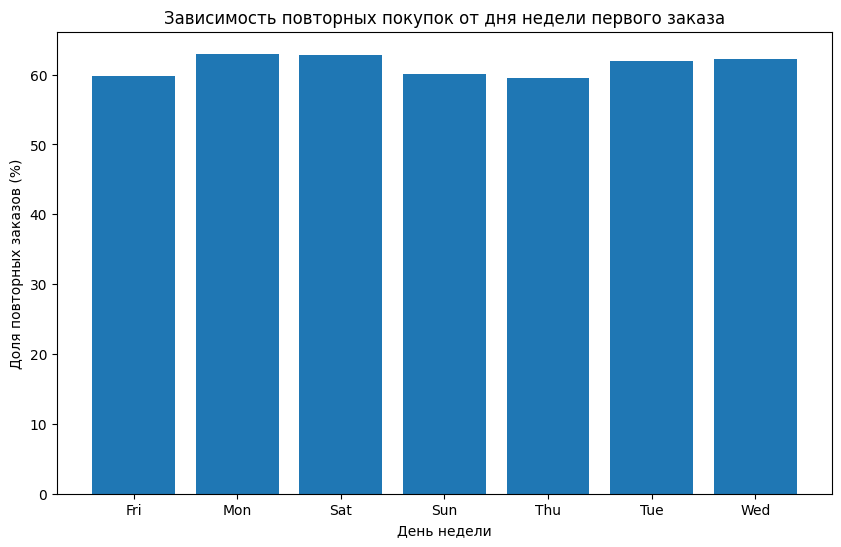

In [69]:
plt.figure(figsize=(10, 6))
plt.bar(info['day_of_week'], info['per_repeat_users'])
plt.xlabel('День недели')
plt.ylabel('Доля повторных заказов (%)')
plt.title('Зависимость повторных покупок от дня недели первого заказа')
plt.show()

Результаты показали, что день недели не сильно влияет на вероятность возврата клиента. Доли повторных заказов, в среднем, находятся на уровне 60%, с небольшим ворастанием в поенедельник и воскресенье (63 и 62%) и проседания в четверг и пятницу (по 59%).

---

**Задача 4.3.2.** Изучите, как средний интервал между заказами влияет на удержание клиентов.

- Рассчитайте среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


Изучим, как средний интервал между заказами влияет на удержание клиентов.

Для этого рассчитаем среднее время между заказами пользователей, совершивших от 2 до 4 заказов и пользователей, совершивших более 5 заказов. 

Дальше исследуем, как средний интервал между заказами влияет на вероятность повторного заказа.

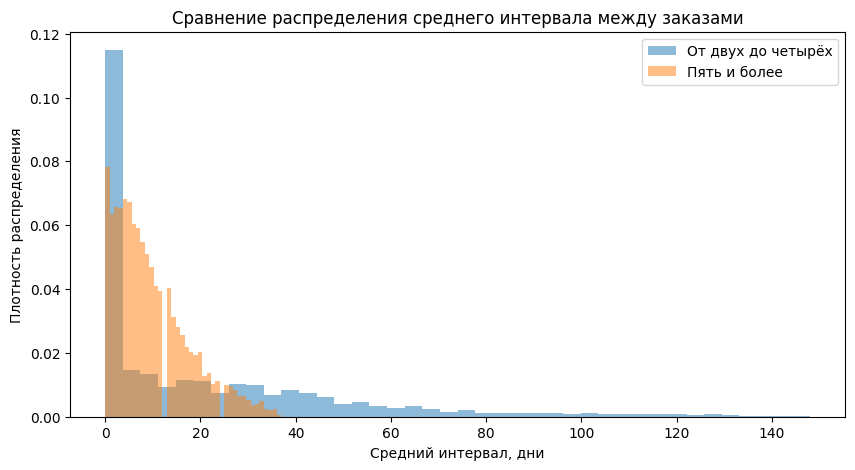

In [70]:
medium_active_users = total_users_profile_filtered[(total_users_profile_filtered
['orders_count'] >=2) & (total_users_profile_filtered
['orders_count'] <= 4)]['avg_time_between_orders']

super_active_users = total_users_profile_filtered[(total_users_profile_filtered
['orders_count'] >=5)]['avg_time_between_orders']



plt.figure(figsize=(10,5))
medium_active_users.plot.hist(bins=40, alpha=0.5, density=True, label='От двух до четырёх')
super_active_users.plot.hist(bins=40, alpha=0.5, density=True, label='Пять и более')
plt.xlabel('Средний интервал, дни')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения среднего интервала между заказами')
plt.legend()
plt.show()

In [71]:
print(medium_active_users.mean())
print(super_active_users.mean())

print(medium_active_users.median())
print(super_active_users.median())

21.3259622113366
9.565423617926072
9.0
8.0


In [72]:
# Выбираем пользователей с хотя бы 2 заказами (чтобы был интервал)
users_with_interval = total_users_profile_filtered[
    total_users_profile_filtered['avg_time_between_orders'].notna()
]

# Корреляция между интервалом и количеством заказов
correlation = users_with_interval['avg_time_between_orders'].corr(
    users_with_interval['orders_count']
)
print(f"Корреляция между интервалом и числом заказов: {correlation:.3f}")

Корреляция между интервалом и числом заказов: -0.214


По графику видно, что обе метрики имеют экспоненциальное распределение. Плотность распределения пользователей сконйентрирована околонулевых значений, но имеет длинный 'хвост' в правую сторону. Пользователи с пятью и более заказанны также имеют хвост, но не такой длинный

По результатам вычислений, среднее значение у людей с двумя-четырьмя, среднее значение получилось больше 21 одного дня, что обуславливается высокими значениями (более 140 дней), а у людей, с 5 и более заказами - больше 9 дней.

По дополнительной проверке по медиане, можно заметить, что медианное среднее значение между покупокй у людей с 2-4 заказами равно 9 дням, а у людей с 5 и более - 8.

По результатам корреляционного анализа наблюдается слабая отрицательная корреляция между интервалом и числом заказов (-0.214). Это значит, что меньше средний интервал между заказами, тем больше заказов совершает пользователь (и наоборот)

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

---

**Задача 4.4.1:** Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов (`total_orders`). При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в `total_orders`. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю `total_orders`, а затем повторите корреляционный анализ. Выделите такие сегменты:
    - 1 заказ;
    - от 2 до 4 заказов;
    - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

---

Рассчитаем коэффициент корреляции `phi_k`  между признаками профиля пользователя и числом заказов:

In [73]:
total_users_profile_filtered.phik_matrix()['orders_count']

interval columns not set, guessing: ['orders_count', 'avg_revenue_rub', 'avg_tickets_count', 'avg_time_between_orders', 'is_two', 'is_five']


user_id                    1.000000
first_order                0.427697
last_order                 0.410737
device_type_canonical      0.030143
region_name                0.117264
service_name               0.029629
event_type_main            0.024723
orders_count               1.000000
avg_revenue_rub            0.219467
avg_tickets_count          0.225348
avg_time_between_orders    0.284665
is_two                     0.308675
is_five                    0.614720
day_of_week                0.059635
Name: orders_count, dtype: float64

Полученные значения неоколонулевые, данные репрезентабельны и их можно визуализировать на тепловой карте

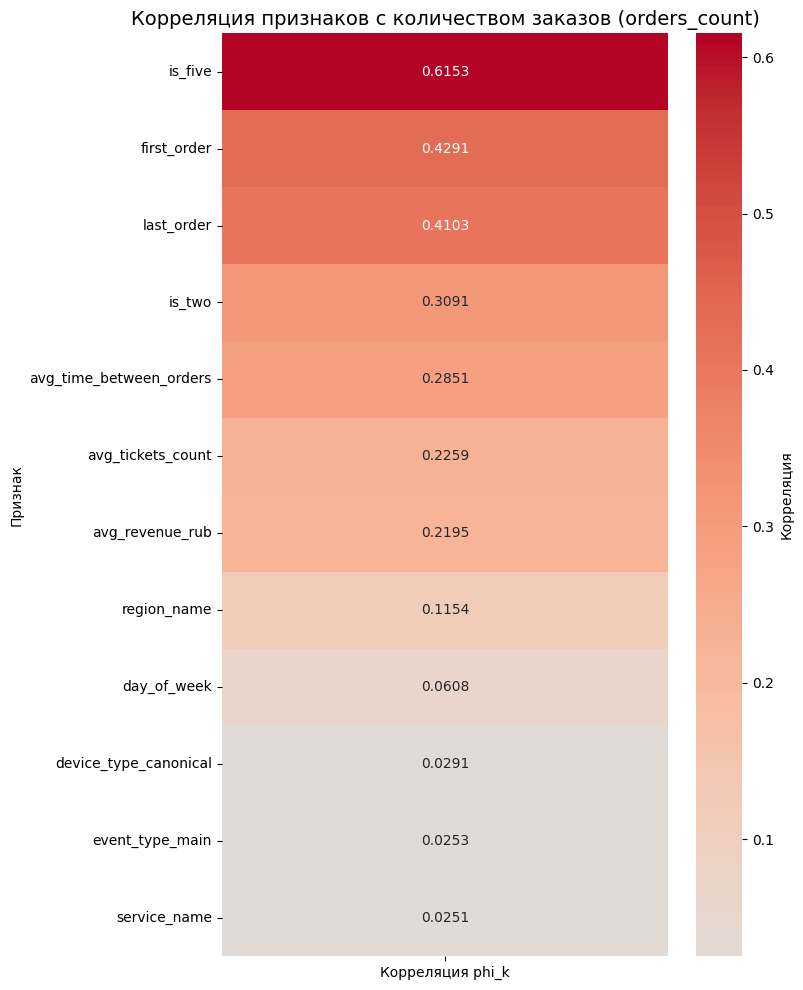

In [74]:
correlations = {
    'first_order': 0.429065,
    'last_order': 0.410308,
    'device_type_canonical': 0.029053,
    'region_name': 0.115396,
    'service_name': 0.025111,
    'event_type_main': 0.025329,
    'avg_revenue_rub': 0.219482,
    'avg_tickets_count': 0.225904,
    'avg_time_between_orders': 0.285059,
    'is_two': 0.309085,
    'is_five': 0.615266,
    'day_of_week': 0.060831
}

# Сортируем для наглядности
correlations_sorted = dict(sorted(correlations.items(), key=lambda x: x[1], reverse=True))
corr_df = pd.DataFrame(list(correlations_sorted.items()), columns=['Признак', 'Корреляция phi_k'])
corr_df = corr_df.set_index('Признак')

# Тепловая карта (вертикальная для читаемости)
plt.figure(figsize=(8, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, fmt='.4f', cbar_kws={'label': 'Корреляция'})
plt.title('Корреляция признаков с количеством заказов (orders_count)', fontsize=14)
plt.tight_layout()
plt.show()

Наиболее связаны с количеством заказов: `is_five`, `first_order`, `last_order`, а также `avg_time_between_orders`, `avg_tickets_count`, `avg_revenue_rub`.

Слабую связь показывают категориальные признаки: день недели, устройство, регион, сервис, тип события.

### 5. Общий вывод и рекомендации

В конце проекта напишите общий вывод и рекомендации: расскажите заказчику, на что нужно обратить внимание. В выводах кратко укажите:

- **Информацию о данных**, с которыми вы работали, и то, как они были подготовлены: например, расскажите о фильтрации данных, переводе тенге в рубли, фильтрации выбросов.
- **Основные результаты анализа.** Например, укажите:
    - Сколько пользователей в выборке? Как распределены пользователи по числу заказов? Какие ещё статистические показатели вы подсчитали важным во время изучения данных?
    - Какие признаки первого заказа связаны с возвратом пользователей?
    - Как связаны средняя выручка и количество билетов в заказе с вероятностью повторных покупок?
    - Какие временные характеристики влияют на удержание (день недели, интервалы между покупками)?
    - Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок согласно результатам корреляционного анализа?
- Дополните выводы информацией, которая покажется вам важной и интересной. Следите за общим объёмом выводов — они должны быть компактными и ёмкими.

В конце предложите заказчику рекомендации о том, как именно действовать в его ситуации. Например, укажите, на какие сегменты пользователей стоит обратить внимание в первую очередь, а какие нуждаются в дополнительных маркетинговых усилиях.

**Общий вывод и рекомендации**

В ходе анализа были выявлены ключевые закономерности поведения пользователей и факторы, влияющие на их возврат на платформу.

**Основные выводы:**

* большинство пользователей совершают ограниченное число заказов, формируя длинный «хвост» распределения;
* первый пользовательский опыт (тип мероприятия, устройство, регион) оказывает значительное влияние на дальнейшее поведение;
* мобильные устройства являются основным каналом взаимодействия;
* выявлены аномальные пользователи с высокой активностью, требующие отдельного анализа.

**Рекомендации:**

* Пользователи с интервалом между покупками менее 10 дней совершают больше заказов,
поэтому рекомендуется запускать триггерные коммуникации в первые 7–10 дней после покупки.
* Пользователи с 2–4 билетами в заказе демонстрируют более высокую лояльность —
стоит таргетировать их семейными и групповыми предложениями.
* Пользователи с высоким средним чеком (5+ заказов) показывают более высокий LTV —
для них можно внедрить премиальные предложения.
